# Phishing Detection — Explainable LLM Fine-Tuning

**Phase 1: Exploratory Data Analysis**

Goal: understand the dataset completely before any modelling decisions.

| Sub-phase | What it does |
|---|---|
| 1a | Environment setup, Drive mount, imports |
| 1b | Load data, parse nested fields, basic inventory |
| 1c | Per-feature table: fire rate, dtype, suggested action |
| 1d | Domain analysis — top domains, per-class, overlap |
| 1e | Time / domain age analysis |
| 1f | Content distributions + 10+ examples per class |
| 1g | XGBoost + SHAP + LOFO feature audit |

All outputs (plots, tables, summary) are saved to `/content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase1/` so we can resume if the session dies.

## 1a — Environment Setup

Mount Drive, install libraries, set seeds, define output paths. Run once per session.

In [3]:
# ── Mount Drive ──────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Install libraries (quiet) ────────────────────────────────────────────────
# tldextract handles registered-domain extraction properly (better than hand-coded TLD lists).
# xgboost + shap + lofo-importance for the feature audit in 1g.
!pip -q install tldextract xgboost shap lofo-importance 2>&1 | tail -3

# ── Imports ──────────────────────────────────────────────────────────────────
import os, json, gc, math, random, warnings
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tldextract

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 80)

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_PATH   = '/content/drive/MyDrive/XAI_Analyzer/50k.jsonl'
OUTPUT_DIR  = Path('/content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase1')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLOTS_DIR = OUTPUT_DIR / 'plots'
TABLES_DIR = OUTPUT_DIR / 'tables'
PLOTS_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)

print(f'Data file:   {DATA_PATH}')
print(f'Output dir:  {OUTPUT_DIR}')
print(f'File exists: {os.path.exists(DATA_PATH)}')
if os.path.exists(DATA_PATH):
    print(f'File size:   {os.path.getsize(DATA_PATH) / 1e6:.1f} MB')

# Matplotlib defaults
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
Data file:   /content/drive/MyDrive/XAI_Analyzer/50k.jsonl
Output dir:  /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase1
File exists: True
File size:   1202.8 MB


## 1b — Load Data & Basic Inventory

Read the JSONL file line by line (robust to malformed rows), flatten the nested `features` dict into top-level columns, and report:

- Total rows parsed vs malformed
- Label distribution (phishing vs benign)
- Column inventory: top-level metadata + flat feature names
- Missing / null patterns
- Duplicate detection (by `id` and by `url`)

This cell **does not drop anything yet** — we look at the raw data first, then decide cleaning rules in Phase 2.

In [31]:
# ── Stream-parse JSONL ───────────────────────────────────────────────────────
# We parse line-by-line rather than load_dataset() so we can count malformed rows
# and inspect schema variations without HuggingFace's strict type inference.
rows = []
n_malformed = 0
n_no_label  = 0

with open(DATA_PATH, encoding='utf-8') as f:
    for line_no, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
        except json.JSONDecodeError:
            n_malformed += 1
            continue
        if 'label' not in obj or obj['label'] not in ('phishing', 'benign'):
            n_no_label += 1
            continue
        rows.append(obj)

print(f'Total parsed rows:   {len(rows):,}')
print(f'Malformed lines:     {n_malformed}')
print(f'Missing/bad label:   {n_no_label}')

# ── Inspect schema of first row ──────────────────────────────────────────────
print('\nTop-level keys in first row:')
for k, v in rows[0].items():
    vtype = type(v).__name__
    if isinstance(v, (dict, list)):
        preview = f'{vtype} with {len(v)} items'
    else:
        preview = repr(v)[:80]
    print(f'  {k:30s} {vtype:10s}  {preview}')

Total parsed rows:   147,524
Malformed lines:     0
Missing/bad label:   0

Top-level keys in first row:
  id                             str         '692c60084325b40e64e3ae2f'
  label                          str         'phishing'
  label_info                     dict        dict with 2 items
  db                             str         'phishing_db'
  collection                     str         'website_content'
  url                            str         'https://masukomu.onamaeweb.jp/max.il/activation/total/'
  final_url                      str         'https://masukomu.onamaeweb.jp/max.il/activation/total/'
  title                          str         'MAX - אימות כרטיס'
  feature_groups                 dict        dict with 3 items
  features                       dict        dict with 126 items


In [32]:
# ── Build flat DataFrame ─────────────────────────────────────────────────────
# Hoist the nested `features` dict to top-level columns, keep core metadata as-is.
# Anything that fails to flatten (variable-schema fields like label_info) stays nested
# and we just ignore it for analysis purposes.

META_COLS = ['id', 'label', 'url', 'final_url', 'title', 'db', 'collection']

flat_records = []
for r in rows:
    rec = {k: r.get(k) for k in META_COLS}
    feats = r.get('features') or {}
    if isinstance(feats, dict):
        rec.update(feats)
    flat_records.append(rec)

df = pd.DataFrame(flat_records)
print(f'DataFrame shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

# ── Label distribution ───────────────────────────────────────────────────────
label_counts = df['label'].value_counts()
print('\nLabel distribution:')
for lbl, c in label_counts.items():
    print(f'  {lbl:10s} {c:>7,d}  ({100*c/len(df):.1f}%)')

# ── Duplicate detection ──────────────────────────────────────────────────────
dup_id  = df['id'].duplicated().sum() if 'id' in df.columns else 'N/A (no id column)'
dup_url = df['url'].duplicated().sum()
print(f'\nDuplicates by id:  {dup_id}')
print(f'Duplicates by url: {dup_url}')
print(f'Empty url rows:    {(df["url"].isna() | (df["url"] == "")).sum()}')

# ── Column inventory ─────────────────────────────────────────────────────────
feature_cols = [c for c in df.columns if c not in META_COLS]
print(f'\nMetadata columns: {len(META_COLS)} — {META_COLS}')
print(f'Feature columns:  {len(feature_cols)}')
print(f'First 10 feature names: {feature_cols[:10]}')

# Free the raw list now that we have the dataframe
del rows, flat_records
gc.collect()

DataFrame shape: 147,524 rows × 133 columns

Label distribution:
  benign      87,924  (59.6%)
  phishing    59,600  (40.4%)

Duplicates by id:  0
Duplicates by url: 5599
Empty url rows:    0

Metadata columns: 7 — ['id', 'label', 'url', 'final_url', 'title', 'db', 'collection']
Feature columns:  126
First 10 feature names: ['url.final_url_length', 'url.requested_url_length', 'url.scheme_is_https', 'url.hostname_length', 'url.registrable_domain_length', 'url.subdomain_length', 'url.path_length', 'url.query_length', 'url.fragment_length', 'url.path_segment_count']


5600

In [33]:
# ── Show the data as a table ─────────────────────────────────────────────────
# Quick look at the actual contents of the DataFrame.
print('── First 5 rows (metadata columns only) ──')
display(df[META_COLS].head(5))

print('\n── First 5 rows (sample of feature columns) ──')
sample_feat_cols = ['url.requested_url_length', 'url.scheme_is_https',
                    'html.form_count', 'html.password_input_count',
                    'html.visible_word_count', 'html.total_tag_count',
                    'html.external_anchor_ratio', 'html.javascript_redirect_present']
sample_feat_cols = [c for c in sample_feat_cols if c in df.columns]
display(df[['label'] + sample_feat_cols].head(5))

print('\n── Numeric summary of feature columns (.describe()) ──')
display(df[feature_cols].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']].head(20))

── First 5 rows (metadata columns only) ──


,id,label,url,final_url,title,db,collection
0,692c60084325b40e64e3ae2f,phishing,https://masukomu.onamaeweb.jp/max.il/activation/total/,https://masukomu.onamaeweb.jp/max.il/activation/total/,MAX - אימות כרטיס,phishing_db,website_content
1,6967423104da27a134161337,phishing,http://veruiozeruinmertfun.weebly.com/,https://veruiozeruinmertfun.weebly.com/,webmail,phishing_db,website_content
2,69e9e2f1dd64eb9591b95747,phishing,http://reurl.cc/zzQ1jy,https://reurl.cc/zzQ1jy,Sign in to your account,phishing_db,website_content
3,69cc4131bc43d9c8ee6c9a31,phishing,https://api-oxdjorr12.veltrazonicapur.ink/Y2Fyb2x5bkBvdmVyc2Vhc2hvcnNlc2Vydm...,https://api-oxdjorr12.veltrazonicapur.ink/Y2Fyb2x5bkBvdmVyc2Vhc2hvcnNlc2Vydm...,Security Verification,phishing_db,website_content
4,696b204b04da27a134162087,phishing,http://www.kejutanwhatsappakhirtahun2018.blogspot.com/?m=1,https://kejutanwhatsappakhirtahun2018.blogspot.com/?m=1,Whatsapp,phishing_db,website_content



── First 5 rows (sample of feature columns) ──


,label,url.requested_url_length,url.scheme_is_https,html.form_count,html.password_input_count,html.visible_word_count,html.total_tag_count,html.external_anchor_ratio,html.javascript_redirect_present
0,phishing,54,1,1,0,118,69,0.000000,0
1,phishing,38,1,1,0,8,158,0.000000,0
2,phishing,22,1,0,0,140,369,0.805556,1
3,phishing,86,1,1,0,14,42,0.000000,0
4,phishing,58,1,0,0,22,190,0.600000,0



── Numeric summary of feature columns (.describe()) ──


,count,mean,std,min,50%,max
url.final_url_length,147524.0,52.680398,69.200429,13.0,38.0,2000.0
url.requested_url_length,147524.0,48.880575,53.070543,13.0,37.0,2000.0
url.scheme_is_https,147524.0,0.973550,0.160470,0.0,1.0,1.0
url.hostname_length,147524.0,20.222926,10.088977,0.0,18.0,167.0
url.registrable_domain_length,147524.0,13.714724,4.891594,4.0,13.0,56.0
url.subdomain_length,147524.0,5.856647,9.927771,0.0,3.0,150.0
url.path_length,147524.0,15.729542,24.051523,0.0,6.0,1939.0
url.query_length,147524.0,8.517828,62.949040,0.0,0.0,1927.0
url.fragment_length,147524.0,0.125905,6.654075,0.0,0.0,1958.0
url.path_segment_count,147524.0,1.044379,1.260013,0.0,1.0,13.0


## 1c — Per-Feature Inventory Table

For every feature column, compute:

- **dtype** and inferred kind (binary / count / ratio / continuous)
- **fire rate** = % of rows where the value is non-zero / non-null
- **mean, std, min, max, missing %**
- **suggested action**: keep / drop (low fire rate) / drop (constant) / review

Features that fire in <1% or >99% of rows carry almost no information for a classifier and are recommended for dropping. We don't actually drop here — we just flag. Phase 1g (XGBoost/SHAP/LOFO) makes the final decision.

In [5]:
# ── Build the feature inventory table ────────────────────────────────────────
inventory = []
n_total = len(df)

for col in feature_cols:
    s = df[col]
    dtype = str(s.dtype)
    n_missing = s.isna().sum()
    n_nonzero = (s.fillna(0) != 0).sum()
    fire_rate = 100 * n_nonzero / n_total

    # Infer feature kind
    if pd.api.types.is_numeric_dtype(s):
        s_clean = s.dropna()
        unique_vals = s_clean.unique()
        if len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1, 0.0, 1.0}):
            kind = 'binary'
        elif s_clean.dtype.kind in ('i', 'u'):
            kind = 'count'
        elif (s_clean.min() >= 0) and (s_clean.max() <= 1):
            kind = 'ratio'
        else:
            kind = 'continuous'
        mean_v, std_v = s_clean.mean(), s_clean.std()
        min_v, max_v = s_clean.min(), s_clean.max()
    else:
        kind = 'non-numeric'
        mean_v = std_v = min_v = max_v = np.nan

    # Suggested action
    if fire_rate < 1.0:
        action = 'drop (low fire rate)'
    elif fire_rate > 99.0 and kind == 'binary':
        action = 'drop (near-constant)'
    elif kind == 'non-numeric':
        action = 'review (non-numeric)'
    else:
        action = 'keep'

    inventory.append({
        'feature':     col,
        'dtype':       dtype,
        'kind':        kind,
        'fire_rate_%': round(fire_rate, 2),
        'missing_%':   round(100 * n_missing / n_total, 2),
        'mean':        mean_v,
        'std':         std_v,
        'min':         min_v,
        'max':         max_v,
        'action':      action,
    })

inv_df = pd.DataFrame(inventory).sort_values('fire_rate_%', ascending=False)
inv_path = TABLES_DIR / 'feature_inventory.csv'
inv_df.to_csv(inv_path, index=False)
print(f'Saved: {inv_path}')

# Summary by action
print('\nFeature inventory summary by suggested action:')
print(inv_df['action'].value_counts().to_string())

# Show flagged features
print('\n── Features flagged for DROP (low fire rate < 1%) ──')
print(inv_df[inv_df['action'].str.startswith('drop')][['feature','kind','fire_rate_%']].to_string(index=False))

print('\n── Top 20 highest fire-rate features ──')
print(inv_df.head(20)[['feature','kind','fire_rate_%','mean']].to_string(index=False))

print('\n── Feature kind distribution ──')
print(inv_df['kind'].value_counts().to_string())

Saved: /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase1/tables/feature_inventory.csv

Feature inventory summary by suggested action:
action
keep                    107
drop (low fire rate)     18
review (non-numeric)      1

── Features flagged for DROP (low fire rate < 1%) ──
                                   feature   kind  fire_rate_%
                   html.meta_refresh_count  count         0.73
                         url.at_sign_count  count         0.72
                       url.hash_sign_count  count         0.69
                       url.fragment_length  count         0.67
html.password_form_external_action_present binary         0.48
              url.extra_double_slash_count  count         0.35
                       url.plus_sign_count  count         0.27
                 url.explicit_port_present binary         0.18
                      url.punycode_present binary         0.16
                    url.host_is_ip_address binary         0.12
        

In [36]:
# ── Per-class fire rate (phishing vs benign) ─────────────────────────────────
# This gives us a quick lift signal BEFORE running any model:
# fire_phish / fire_benign tells us which features actually distinguish the classes.
ph_mask = df['label'] == 'phishing'
be_mask = df['label'] == 'benign'
n_ph, n_be = ph_mask.sum(), be_mask.sum()

class_table = []
for col in feature_cols:
    if not pd.api.types.is_numeric_dtype(df[col]):
        continue
    fire_ph = 100 * (df.loc[ph_mask, col].fillna(0) != 0).sum() / n_ph
    fire_be = 100 * (df.loc[be_mask, col].fillna(0) != 0).sum() / n_be
    mean_ph = df.loc[ph_mask, col].fillna(0).mean()
    mean_be = df.loc[be_mask, col].fillna(0).mean()
    lift = (fire_ph / fire_be) if fire_be > 0 else np.inf
    class_table.append({
        'feature':       col,
        'fire_ph_%':     round(fire_ph, 2),
        'fire_be_%':     round(fire_be, 2),
        'mean_ph':       mean_ph,
        'mean_be':       mean_be,
        'lift':          round(lift, 2) if np.isfinite(lift) else None,
        'direction':     'phishing' if fire_ph > fire_be else 'benign',
    })

class_df = pd.DataFrame(class_table)
class_path = TABLES_DIR / 'feature_per_class.csv'
class_df.to_csv(class_path, index=False)
print(f'Saved: {class_path}')

print('\n── Top 15 phishing-leaning features (highest lift) ──')
print(class_df.sort_values('lift', ascending=False).head(15).to_string(index=False))

print('\n── Top 15 benign-leaning features (lowest lift, lift > 0) ──')
print(class_df[class_df['lift'] > 0].sort_values('lift').head(15).to_string(index=False))

Saved: /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase1/tables/feature_per_class.csv

── Top 15 phishing-leaning features (highest lift) ──
                                   feature  fire_ph_%  fire_be_%  mean_ph  mean_be  lift direction
                     url.parenthesis_count       4.27       0.05 0.168423 0.001319 91.61  phishing
               url.https_token_in_hostname       0.07       0.00 0.000688 0.000011 60.48  phishing
                         url.at_sign_count       1.74       0.03 0.019413 0.000353 52.75  phishing
html.password_form_external_action_present       0.94       0.16 0.009446 0.001570  6.02  phishing
                    url.host_is_ip_address       0.23       0.05 0.002315 0.000455  5.09  phishing
                        url.asterisk_count       0.12       0.02 0.002349 0.001137  4.99  phishing
                 url.explicit_port_present       0.34       0.08 0.003406 0.000773  4.40  phishing
    html.password_form_null_action_present     

In [7]:
# ── Full list of all features ────────────────────────────────────────────────
print(f'All {len(feature_cols)} features in the dataset:\n')
for i, f in enumerate(feature_cols, 1):
    print(f'  {i:3d}. {f}')

# Save full list to a text file too
with open(TABLES_DIR / 'all_features.txt', 'w') as f:
    for c in feature_cols:
        f.write(c + '\n')
print(f'\nSaved: {TABLES_DIR / "all_features.txt"}')

All 126 features in the dataset:

    1. url.final_url_length
    2. url.requested_url_length
    3. url.scheme_is_https
    4. url.hostname_length
    5. url.registrable_domain_length
    6. url.subdomain_length
    7. url.path_length
    8. url.query_length
    9. url.fragment_length
   10. url.path_segment_count
   11. url.query_parameter_count
   12. url.subdomain_label_count
   13. url.dot_count
   14. url.hostname_dot_count
   15. url.hyphen_count
   16. url.registrable_domain_hyphen_count
   17. url.underscore_count
   18. url.slash_count
   19. url.extra_double_slash_count
   20. url.question_mark_count
   21. url.equals_sign_count
   22. url.ampersand_count
   23. url.at_sign_count
   24. url.percent_sign_count
   25. url.hash_sign_count
   26. url.tilde_count
   27. url.plus_sign_count
   28. url.asterisk_count
   29. url.parenthesis_count
   30. url.square_bracket_count
   31. url.curly_bracket_count
   32. url.angle_bracket_count
   33. url.digit_count
   34. url.hostname_d

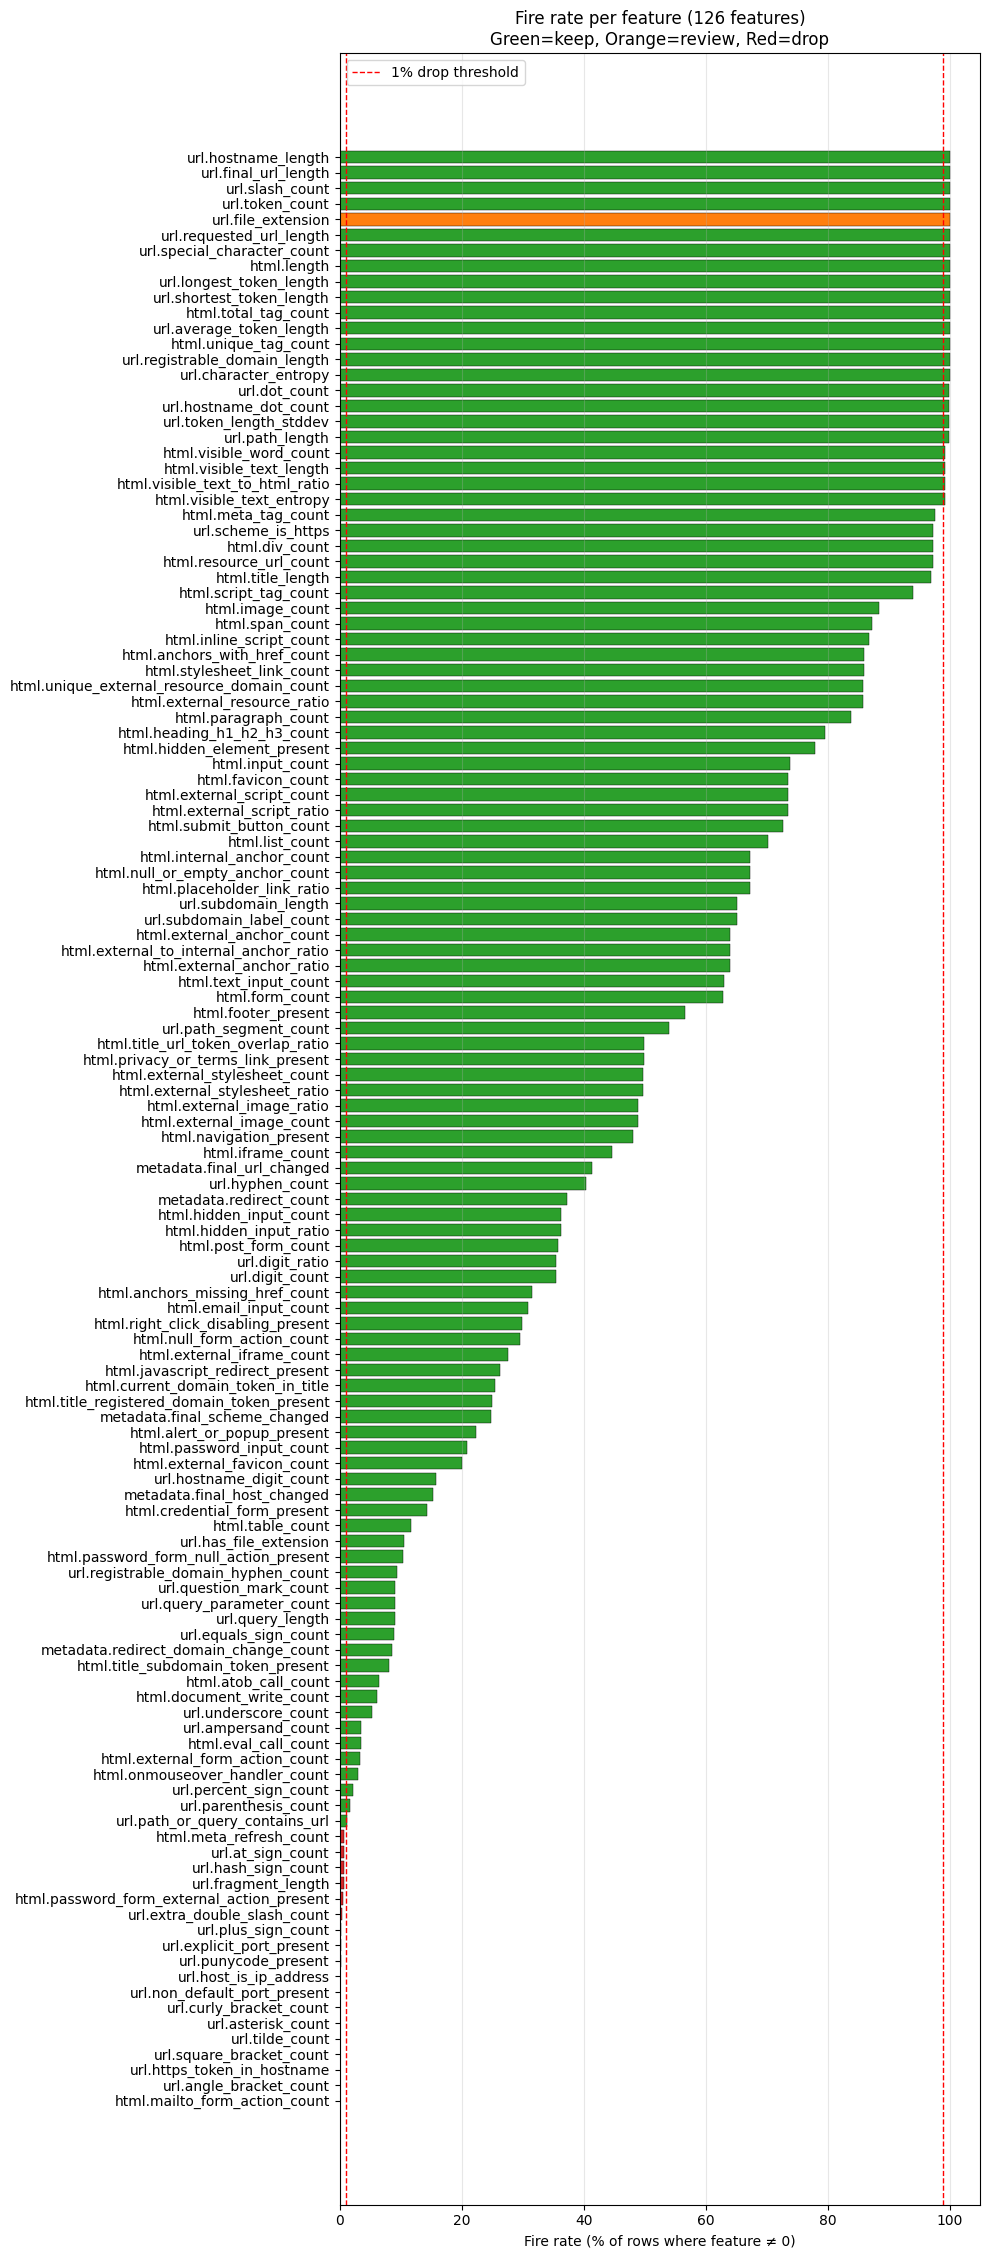

Saved: /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase1/plots/fire_rate_bar_chart.png


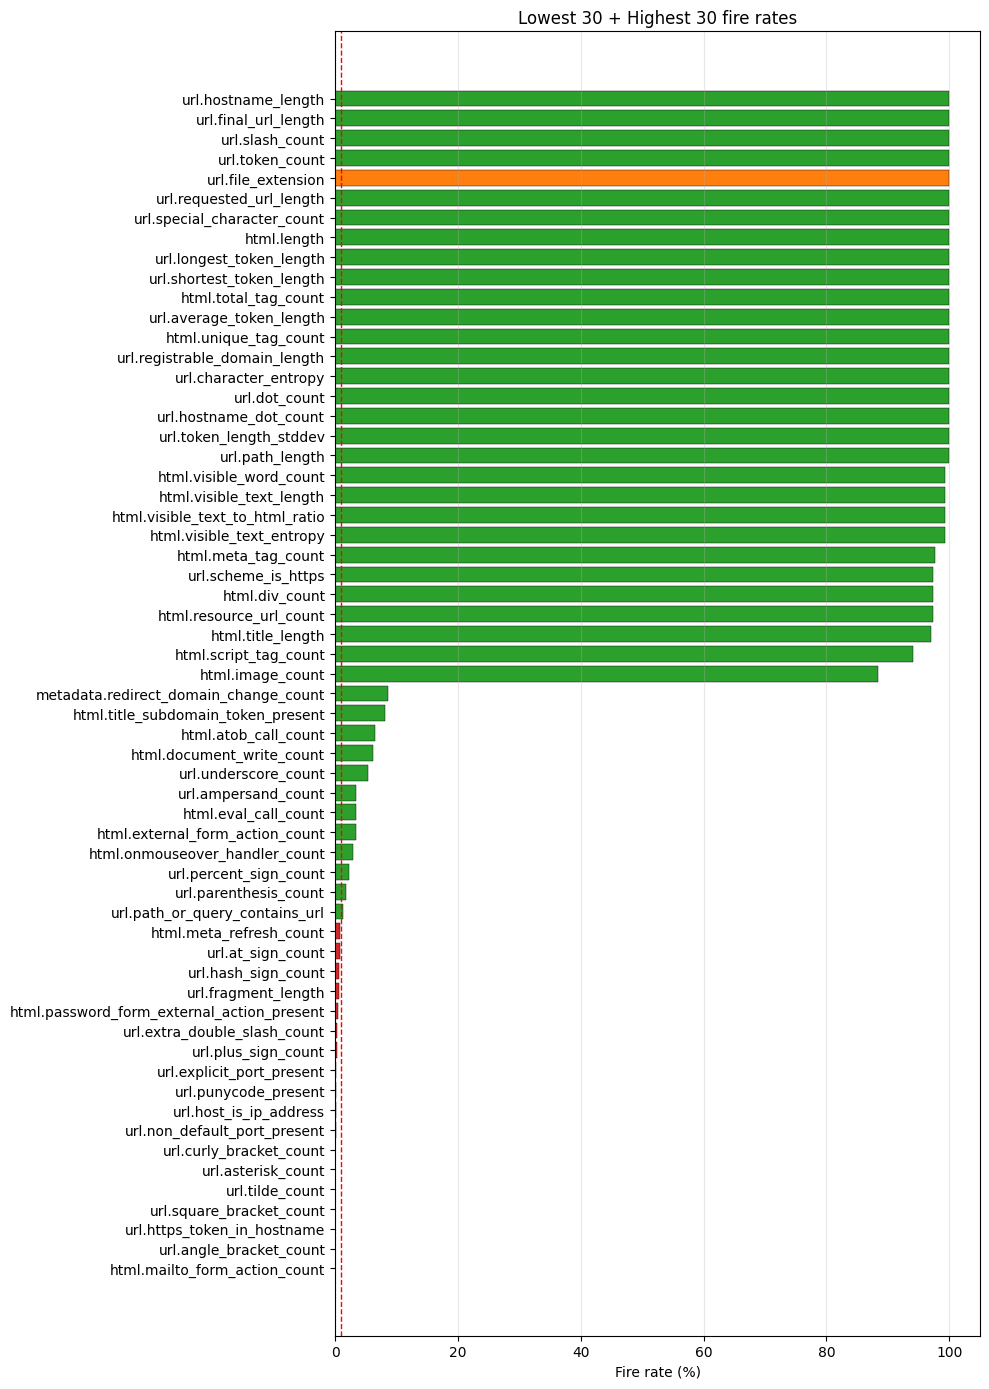

In [8]:
# ── Fire-rate bar chart ──────────────────────────────────────────────────────
# Visualize the inventory: every feature, sorted by fire rate.
inv_sorted = inv_df.sort_values('fire_rate_%', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(20, len(inv_sorted) * 0.18)))
colors = ['#d62728' if a.startswith('drop') else
          '#ff7f0e' if a.startswith('review') else
          '#2ca02c' for a in inv_sorted['action']]
ax.barh(inv_sorted['feature'], inv_sorted['fire_rate_%'], color=colors, edgecolor='black', linewidth=0.3)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1, label='1% drop threshold')
ax.axvline(99.0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Fire rate (% of rows where feature ≠ 0)')
ax.set_title(f'Fire rate per feature ({len(feature_cols)} features)\n'
             'Green=keep, Orange=review, Red=drop')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fire_rate_bar_chart.png')
plt.show()
print(f'Saved: {PLOTS_DIR / "fire_rate_bar_chart.png"}')

# Also: zoomed-in version showing top/bottom 30 features only, easier to read
top_bottom = pd.concat([inv_sorted.head(30), inv_sorted.tail(30)])
fig, ax = plt.subplots(figsize=(10, 14))
colors_zoom = ['#d62728' if a.startswith('drop') else '#ff7f0e' if a.startswith('review') else '#2ca02c'
               for a in top_bottom['action']]
ax.barh(top_bottom['feature'], top_bottom['fire_rate_%'], color=colors_zoom, edgecolor='black', linewidth=0.3)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Fire rate (%)')
ax.set_title('Lowest 30 + Highest 30 fire rates')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fire_rate_top_bottom.png')
plt.show()

## 1d — Domain Analysis

Phishing datasets are notorious for **domain dominance**: one platform (e.g., `azurewebsites.net`, `pages.dev`, `weebly.com`) provides thousands of phishing samples. If we don't account for this, the model just memorizes platforms instead of learning phishing patterns. This is the single most important EDA finding for justifying the domain cap + domain-aware split later.

We extract the **registered domain** (eTLD+1) using `tldextract`, then report:

- Unique registered domains per class
- Top 20 domains per class with URL counts
- URLs-per-domain distribution + histogram
- Domains that appear in BOTH classes (signal for caution)

In [37]:
# ── Extract registered domain for every row ──────────────────────────────────
# tldextract handles two-part TLDs (co.uk, com.au, etc.) and weird cases properly,
# unlike a hand-coded TLD list.
_extractor = tldextract.TLDExtract(suffix_list_urls=None, cache_dir=None)  # offline OK

def get_registered_domain(url):
    if not url or not isinstance(url, str):
        return ''
    try:
        ext = _extractor(url)
        if ext.domain and ext.suffix:
            return f'{ext.domain}.{ext.suffix}'.lower()
        return (ext.domain or '').lower()
    except Exception:
        return ''

df['registered_domain'] = df['url'].apply(get_registered_domain)
n_empty_dom = (df['registered_domain'] == '').sum()
print(f'Rows with empty registered domain: {n_empty_dom}')

# ── Per-class domain stats ───────────────────────────────────────────────────
ph_doms = df.loc[ph_mask, 'registered_domain']
be_doms = df.loc[be_mask, 'registered_domain']

ph_dom_counts = ph_doms.value_counts()
be_dom_counts = be_doms.value_counts()

print(f'\nUnique domains (phishing): {ph_dom_counts.size:,}')
print(f'Unique domains (benign):   {be_dom_counts.size:,}')
print(f'Domains appearing in BOTH classes: {len(set(ph_dom_counts.index) & set(be_dom_counts.index)):,}')

print('\n── URLs per domain distribution ──')
for label, cnts in [('Phishing', ph_dom_counts), ('Benign', be_dom_counts)]:
    print(f'{label}:')
    print(f'   max URLs from one domain:  {cnts.max():,}')
    print(f'   median:                    {cnts.median():.0f}')
    print(f'   mean:                      {cnts.mean():.1f}')
    print(f'   domains with 1 URL:        {(cnts == 1).sum():,} ({100*(cnts==1).sum()/len(cnts):.1f}%)')
    print(f'   domains with >100 URLs:    {(cnts > 100).sum()}')
    print(f'   domains with >1000 URLs:   {(cnts > 1000).sum()}')

print('\n── Top 20 phishing domains ──')
print(ph_dom_counts.head(20).to_string())

print('\n── Top 20 benign domains ──')
print(be_dom_counts.head(20).to_string())

Rows with empty registered domain: 0

Unique domains (phishing): 17,264
Unique domains (benign):   40,326
Domains appearing in BOTH classes: 223

── URLs per domain distribution ──
Phishing:
   max URLs from one domain:  4,023
   median:                    1
   mean:                      3.5
   domains with 1 URL:        13,811 (80.0%)
   domains with >100 URLs:    51
   domains with >1000 URLs:   7
Benign:
   max URLs from one domain:  1,510
   median:                    1
   mean:                      2.2
   domains with 1 URL:        30,662 (76.0%)
   domains with >100 URLs:    10
   domains with >1000 URLs:   1

── Top 20 phishing domains ──
registered_domain
github.io               4023
pages.dev               2673
azurewebsites.net       2481
weebly.com              2112
vercel.app              1999
dweb.link               1601
ipfs.io                 1492
webflow.io               944
robiox.com.py            701
roblox.com.ge            634
netlify.app              595
blogspot.

Top 20 domains that appear in BOTH classes:
           domain  phish_count  benign_count  total
        github.io         4023            97   4120
        pages.dev         2673           539   3212
azurewebsites.net         2481             3   2484
       weebly.com         2112            48   2160
       vercel.app         1999            42   2041
       webflow.io          944             7    951
      netlify.app          595            43    638
     blogspot.com          580            48    628
      dynadot.com          383            11    394
      edgeone.app          276             8    284
          icp0.io          253           233    486
      workers.dev          243             5    248
      duckdns.org          223             6    229
       gitbook.io          184             1    185
           ru.com          137             2    139
    amazonaws.com          133            13    146
           sa.com          130             4    134
          web.app   

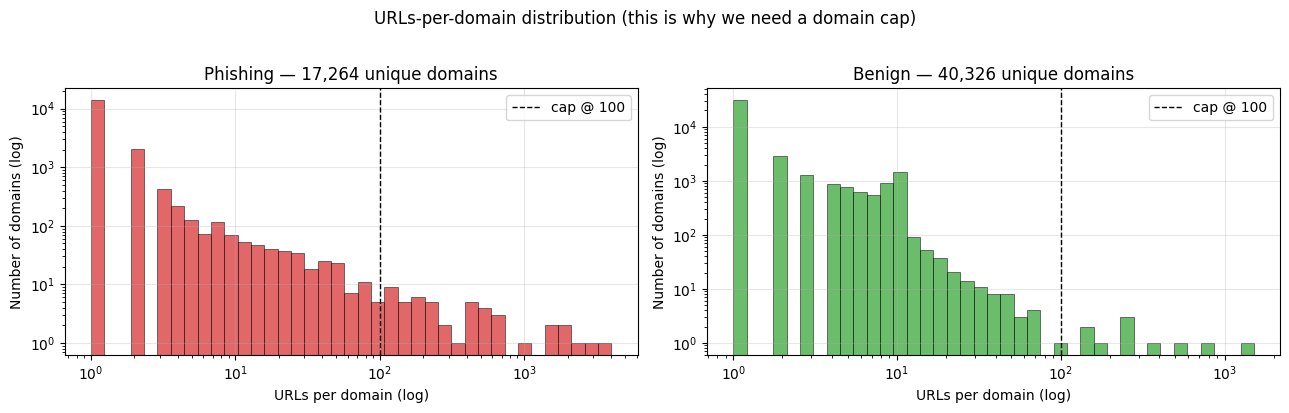

Saved: /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase1/plots/urls_per_domain_histogram.png


In [10]:
# ── Domains appearing in BOTH classes — important for split correctness ──────
shared = set(ph_dom_counts.index) & set(be_dom_counts.index)
shared_df = pd.DataFrame({
    'domain': list(shared),
    'phish_count': [ph_dom_counts[d] for d in shared],
    'benign_count': [be_dom_counts[d] for d in shared],
}).sort_values('phish_count', ascending=False)
shared_df['total'] = shared_df['phish_count'] + shared_df['benign_count']

shared_df.to_csv(TABLES_DIR / 'shared_domains.csv', index=False)
print(f'Top 20 domains that appear in BOTH classes:')
print(shared_df.head(20).to_string(index=False))

# ── Histogram: URLs-per-domain (log scale, both classes) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, cnts, title, color in [
    (axes[0], ph_dom_counts, f'Phishing — {len(ph_dom_counts):,} unique domains', '#d62728'),
    (axes[1], be_dom_counts, f'Benign — {len(be_dom_counts):,} unique domains',   '#2ca02c'),
]:
    ax.hist(cnts.values, bins=np.logspace(0, np.log10(cnts.max()+1), 40),
            color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('URLs per domain (log)')
    ax.set_ylabel('Number of domains (log)')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.axvline(100, color='black', linestyle='--', linewidth=1, label='cap @ 100')
    ax.legend()
plt.suptitle('URLs-per-domain distribution (this is why we need a domain cap)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'urls_per_domain_histogram.png')
plt.show()
print(f'Saved: {PLOTS_DIR / "urls_per_domain_histogram.png"}')

## 1e — Time & Domain Age Analysis

Two separate questions:

1. **When were these pages crawled?** (their age in our dataset). The MongoDB `id` field encodes crawl time in its first 8 hex characters. We extract this and plot the histogram.
2. **How old is the registered domain itself?** (WHOIS-style age). We first check whether any column in the data carries this. If yes, we use it. If no, we note that and discuss next steps before proceeding.

IDs decodable as MongoDB ObjectID (valid timestamp): 98,188 (66.6%)
IDs that are NOT ObjectIDs (UUIDs etc., no timestamp): 49,336

Crawl date range (valid IDs only): 2025-11-10 11:52:52 → 2026-05-08 01:20:19
Span: 178 days


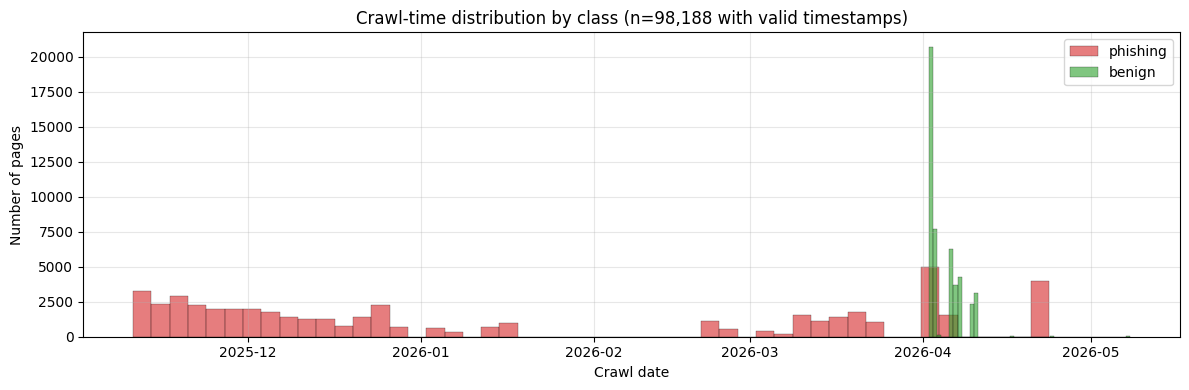


Crawl-time coverage by class:
  phishing: 50,000/59,600 (83.9%) have valid crawl date
  benign: 48,188/87,924 (54.8%) have valid crawl date


In [13]:
# ── 1. Crawl time from MongoDB ObjectID ──────────────────────────────────────
# Some IDs are MongoDB ObjectIDs (24-char hex) — first 8 chars decode to Unix seconds.
# Others are UUIDs (e.g. '019d622d-4...') — these have no timestamp; we skip them.
import re

OBJECTID_RE = re.compile(r'^[0-9a-f]{24}$')

def oid_to_timestamp(oid):
    if not isinstance(oid, str) or not OBJECTID_RE.match(oid):
        return None
    try:
        ts = int(oid[:8], 16)
        # Sanity: must be a real-world date (2010-2030 range)
        if 1262304000 <= ts <= 1893456000:
            return ts
    except ValueError:
        pass
    return None

df['crawl_ts'] = df['id'].apply(oid_to_timestamp)

# Initialize 'crawl_date' column with NaT
df['crawl_date'] = pd.NaT

# Only apply to_datetime to non-null timestamps, ensuring they are integers
valid_ts_mask = df['crawl_ts'].notna()
df.loc[valid_ts_mask, 'crawl_date'] = pd.to_datetime(
    df.loc[valid_ts_mask, 'crawl_ts'].astype(np.int64),
    unit='s',
    errors='coerce'
)
n_no_ts = df['crawl_ts'].isna().sum()
n_with_ts = df['crawl_ts'].notna().sum()

print(f'IDs decodable as MongoDB ObjectID (valid timestamp): {n_with_ts:,} ({100*n_with_ts/len(df):.1f}%)')
print(f'IDs that are NOT ObjectIDs (UUIDs etc., no timestamp): {n_no_ts:,}')

if n_with_ts > 0:
    print(f'\nCrawl date range (valid IDs only): '
          f'{df["crawl_date"].min()} → {df["crawl_date"].max()}')
    print(f'Span: {(df["crawl_date"].max() - df["crawl_date"].min()).days} days')

    fig, ax = plt.subplots(figsize=(12, 4))
    for lbl, color in [('phishing', '#d62728'), ('benign', '#2ca02c')]:
        ax.hist(df.loc[df['label']==lbl, 'crawl_date'].dropna(),
                bins=50, alpha=0.6, label=lbl, color=color, edgecolor='black', linewidth=0.3)
    ax.set_xlabel('Crawl date')
    ax.set_ylabel('Number of pages')
    ax.set_title(f'Crawl-time distribution by class (n={n_with_ts:,} with valid timestamps)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'crawl_time_histogram.png')
    plt.show()

    # Per-class crawl coverage
    print('\nCrawl-time coverage by class:')
    for lbl in ['phishing', 'benign']:
        mask = (df['label']==lbl)
        n_total = mask.sum()
        n_dated = df.loc[mask, 'crawl_ts'].notna().sum() # Corrected: count non-null crawl_ts for the label
        print(f'  {lbl}: {n_dated:,}/{n_total:,} ({100*n_dated/n_total:.1f}%) have valid crawl date')

In [14]:
# ── 2. Check for domain-age features in the dataset ──────────────────────────
# Strict check: look for columns that genuinely encode a timestamp/age, not just
# columns whose name happens to contain a substring like 'age' or 'created'.
print('Looking for genuine domain-age / WHOIS columns...')
print(f'\nAll {len(df.columns)} columns in dataset (full list):\n')
for c in sorted(df.columns):
    print(f'  - {c}')

# Strict: column name must contain whois OR domain_age OR registration_date OR creation_date etc.
STRICT_AGE_PATTERNS = ['whois', 'domain_age', 'registration_date', 'creation_date',
                       'registered_on', 'days_since_registration', 'domain_created',
                       'first_seen', 'registrar']
real_age_cols = [c for c in df.columns if any(p in c.lower() for p in STRICT_AGE_PATTERNS)]

print('\n' + '═' * 70)
if real_age_cols:
    print(f'  ✓ FOUND {len(real_age_cols)} genuine domain-age column(s):')
    print('═' * 70)
    for c in real_age_cols:
        s = df[c]
        print(f'  {c}  dtype={s.dtype}  non-null={s.notna().sum():,}')
        print(f'    sample: {s.dropna().head(5).tolist()}')
else:
    print('  ✗ NO domain-age column found in the dataset.')
    print('═' * 70)
    print('  The dataset does NOT carry WHOIS / registration-age information.')
    print('  This means the <1yr vs >1yr split cannot be done directly from the data.')
    print('')
    print('  Options for handling this in the thesis:')
    print('    (a) DROP the domain-age analysis. Use crawl-time bins as the temporal axis')
    print('        for splitting (we already have crawl date from MongoDB ObjectIDs).')
    print('    (b) Run WHOIS on a sample (200-500 domains per class) for the thesis')
    print('        narrative only — ~30 min runtime, ~30% will fail due to privacy.')
    print('    (c) Use crawl-time as a PROXY for domain freshness — but this is')
    print('        NOT the same thing and should be labelled carefully.')
    print('')
    print('  Recommendation: (a) — the domain cap + domain-aware split (Phase 2)')
    print('  already prevents domain dominance, which was the real concern.')

Looking for genuine domain-age / WHOIS columns...

All 136 columns in dataset (full list):

  - collection
  - crawl_date
  - crawl_ts
  - db
  - final_url
  - html.alert_or_popup_present
  - html.anchors_missing_href_count
  - html.anchors_with_href_count
  - html.atob_call_count
  - html.credential_form_present
  - html.current_domain_token_in_title
  - html.div_count
  - html.document_write_count
  - html.email_input_count
  - html.eval_call_count
  - html.external_anchor_count
  - html.external_anchor_ratio
  - html.external_favicon_count
  - html.external_form_action_count
  - html.external_iframe_count
  - html.external_image_count
  - html.external_image_ratio
  - html.external_resource_ratio
  - html.external_script_count
  - html.external_script_ratio
  - html.external_stylesheet_count
  - html.external_stylesheet_ratio
  - html.external_to_internal_anchor_ratio
  - html.favicon_count
  - html.footer_present
  - html.form_count
  - html.heading_h1_h2_h3_count
  - html.hidden_e

## 1f — Content Distributions & Worked Examples

Three deliverables:

1. Distributions of the most relevant content features (visible word count, total tag count, form count, password input count) — phishing pages are typically much shorter and lighter than benign ones; the histograms confirm this.
2. **10 random phishing examples** (full row, pretty-printed) — so we know what we're working with.
3. **10 random benign examples**.
4. Edge cases: a near-empty page, a content-rich page, a row where multiple suspicious flags fire.

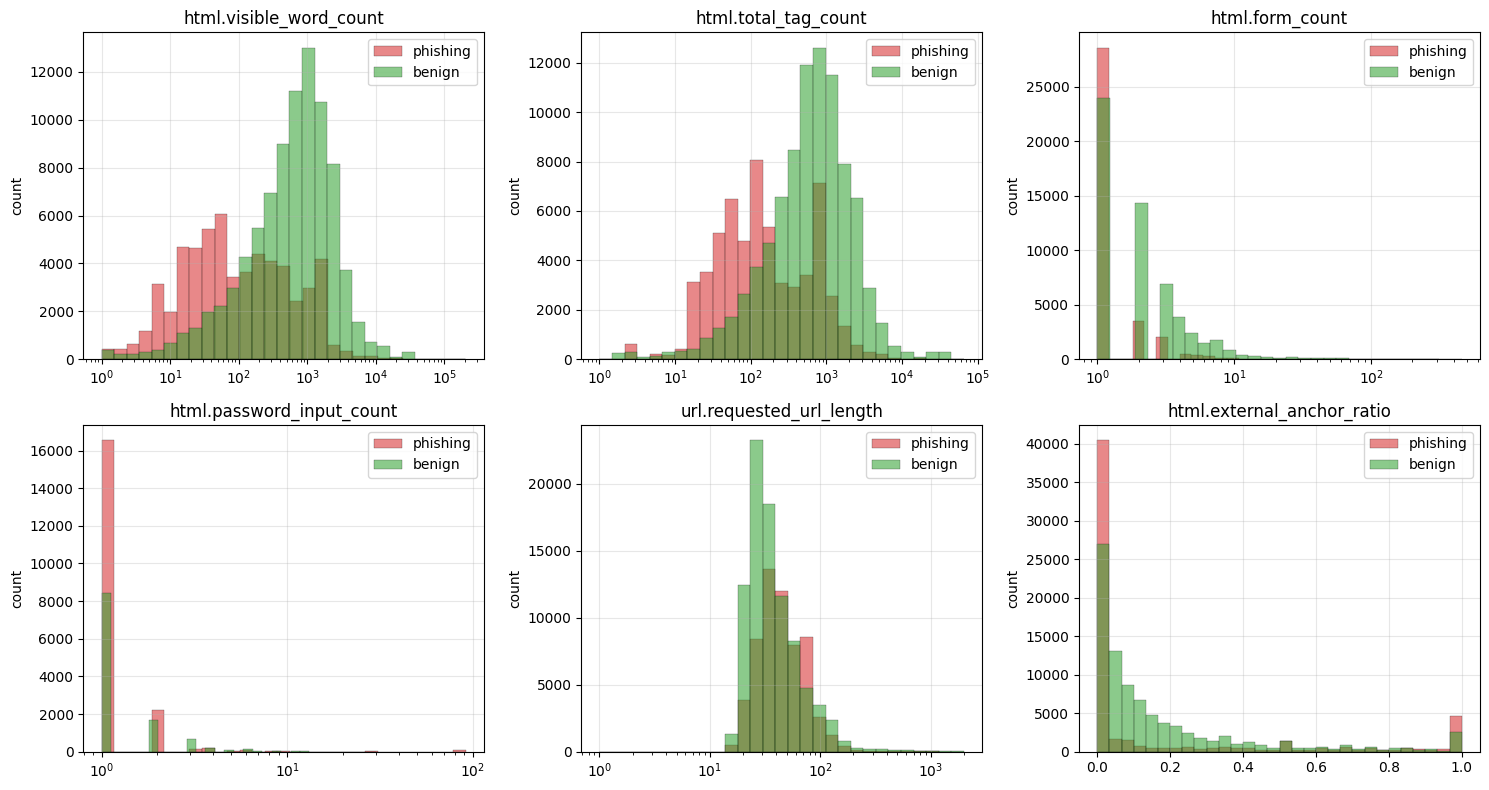

Saved: /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase1/plots/content_feature_distributions.png


In [15]:
# ── Distributions of key content features ────────────────────────────────────
content_features = [
    'html.visible_word_count',
    'html.total_tag_count',
    'html.form_count',
    'html.password_input_count',
    'url.requested_url_length',
    'html.external_anchor_ratio',
]
content_features = [c for c in content_features if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), content_features):
    for lbl, color in [('phishing', '#d62728'), ('benign', '#2ca02c')]:
        vals = df.loc[df['label']==lbl, feat].dropna()
        if feat in ('html.external_anchor_ratio',):
            ax.hist(vals, bins=30, alpha=0.55, label=lbl, color=color, edgecolor='black', linewidth=0.3)
        else:
            # Log-scale for heavy-tail count features
            vals_pos = vals[vals > 0]
            if len(vals_pos) > 0:
                bins = np.logspace(0, np.log10(vals_pos.max()+1), 30)
                ax.hist(vals_pos, bins=bins, alpha=0.55, label=lbl, color=color, edgecolor='black', linewidth=0.3)
                ax.set_xscale('log')
    ax.set_title(feat)
    ax.set_ylabel('count')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'content_feature_distributions.png')
plt.show()
print(f'Saved: {PLOTS_DIR / "content_feature_distributions.png"}')

In [16]:
# ── 10 random phishing + 10 random benign examples ───────────────────────────
# Show many features per example so you can see the full picture.
EXAMPLE_FEATURE_COLS = [
    # URL features
    'url.requested_url_length', 'url.scheme_is_https', 'url.subdomain_length',
    'url.hostname_length', 'url.path_length', 'url.digit_ratio',
    'url.character_entropy', 'url.hyphen_count', 'url.host_is_ip_address',
    # HTML structure
    'html.total_tag_count', 'html.visible_word_count', 'html.script_tag_count',
    'html.iframe_count', 'html.external_iframe_count',
    # Forms / credentials
    'html.form_count', 'html.password_input_count', 'html.email_input_count',
    'html.credential_form_present', 'html.external_form_action_count',
    # Links
    'html.internal_anchor_count', 'html.external_anchor_count',
    'html.external_anchor_ratio', 'html.placeholder_link_ratio',
    # Brand / title
    'html.current_domain_token_in_title', 'html.title_registered_domain_token_present',
    'html.title_subdomain_token_present',
    # Suspicious behaviour
    'html.javascript_redirect_present', 'html.right_click_disabling_present',
    'html.alert_or_popup_present', 'html.eval_call_count',
    # Redirects
    'metadata.redirect_count', 'metadata.final_scheme_changed', 'metadata.final_host_changed',
]
EXAMPLE_FEATURE_COLS = [c for c in EXAMPLE_FEATURE_COLS if c in df.columns]

def show_examples_rich(subset, n, title):
    sample = subset.sample(n=min(n, len(subset)), random_state=SEED)
    print('\n' + '═' * 100)
    print(f'  {title}  (n={len(sample)})')
    print('═' * 100)
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        print(f'\n┌─[{i}] label={row["label"]}  id={str(row.get("id","?"))[:24]}')
        print(f'│ url:      {str(row["url"])[:95]}')
        print(f'│ title:    {str(row.get("title","") or "")[:95]}')
        print(f'│ domain:   {row["registered_domain"]}')
        print(f'│ ─ FEATURES (non-zero only) ─')
        for c in EXAMPLE_FEATURE_COLS:
            val = row[c]
            if pd.isna(val) or val == 0 or val == 0.0:
                continue
            if isinstance(val, float):
                val_str = f'{val:.4f}' if val < 1 else f'{val:.2f}'
            else:
                val_str = str(val)
            print(f'│   {c:50s} = {val_str}')
        print('└' + '─' * 99)

show_examples_rich(df[ph_mask], 10, '10 random PHISHING examples')
show_examples_rich(df[be_mask], 10, '10 random BENIGN examples')


════════════════════════════════════════════════════════════════════════════════════════════════════
  10 random PHISHING examples  (n=10)
════════════════════════════════════════════════════════════════════════════════════════════════════

┌─[1] label=phishing  id=69af3273449cf15ca553e074
│ url:      https://durgeshverma9919.github.io/amazon-clone/
│ title:    amazon
│ domain:   github.io
│ ─ FEATURES (non-zero only) ─
│   url.requested_url_length                           = 48
│   url.scheme_is_https                                = 1
│   url.subdomain_length                               = 16
│   url.hostname_length                                = 26
│   url.path_length                                    = 14
│   url.digit_ratio                                    = 0.0833
│   url.character_entropy                              = 4.49
│   url.hyphen_count                                   = 1
│   html.total_tag_count                               = 181
│   html.visible_word_count   

In [17]:
# ── Edge-case examples ───────────────────────────────────────────────────────
# (1) Near-empty pages (visible_word_count == 0)
# (2) Content-rich pages (top 1% by tag count)
# (3) Pages where many suspicious flags fire

print('═' * 90)
print('  EDGE CASES')
print('═' * 90)

if 'html.visible_word_count' in df.columns:
    empty = df[df['html.visible_word_count'] == 0]
    print(f'\n[a] Pages with zero visible words: {len(empty)} '
          f'({(empty["label"]=="phishing").sum()} phish / {(empty["label"]=="benign").sum()} benign)')
    if len(empty):
        ex = empty.sample(min(3, len(empty)), random_state=SEED)
        for _, r in ex.iterrows():
            print(f'    label={r["label"]}  url={r["url"][:80]}...  title={r.get("title","")[:40]!r}')

if 'html.total_tag_count' in df.columns:
    threshold = df['html.total_tag_count'].quantile(0.99)
    rich = df[df['html.total_tag_count'] >= threshold]
    print(f'\n[b] Top-1% content-rich pages ({threshold:.0f}+ tags): {len(rich)} '
          f'({(rich["label"]=="phishing").sum()} phish / {(rich["label"]=="benign").sum()} benign)')
    if len(rich):
        ex = rich.sample(min(3, len(rich)), random_state=SEED)
        for _, r in ex.iterrows():
            print(f'    label={r["label"]}  url={r["url"][:80]}...  tags={r["html.total_tag_count"]:.0f}')

# (c) Many suspicious flags fire — count binary phishing-leaning features that are 1
PHISHING_LIKE = [c for c in df.columns if c.startswith(('url.', 'html.')) and
                  set(df[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
df['_n_binary_flags'] = df[PHISHING_LIKE].fillna(0).sum(axis=1)
thr2 = df['_n_binary_flags'].quantile(0.99)
flaggy = df[df['_n_binary_flags'] >= thr2]
print(f'\n[c] Pages with most binary flags firing ({thr2:.0f}+ of {len(PHISHING_LIKE)} flags): {len(flaggy)}')
if len(flaggy):
    ex = flaggy.sample(min(3, len(flaggy)), random_state=SEED)
    for _, r in ex.iterrows():
        print(f'    label={r["label"]}  url={r["url"][:80]}...  flags={r["_n_binary_flags"]:.0f}')

df.drop(columns=['_n_binary_flags'], inplace=True)

══════════════════════════════════════════════════════════════════════════════════════════
  EDGE CASES
══════════════════════════════════════════════════════════════════════════════════════════

[a] Pages with zero visible words: 985 (643 phish / 342 benign)
    label=phishing  url=https://meridiancondominiumsales.com/?Gx1q4Z9lFcF1bF2he...  title=''
    label=phishing  url=https://youweachou.jiowale.me.uk/lpAzg4z!mtRPiw5/$3mail@a.b.c0/...  title=''
    label=benign  url=https://obqj2.com/...  title=''

[b] Top-1% content-rich pages (7159+ tags): 1476 (139 phish / 1337 benign)
    label=benign  url=http://chaingpt.com/...  tags=12615
    label=benign  url=https://www.uhc.com/...  tags=14752
    label=benign  url=https://cdn.fun888lao.com/...  tags=39042

[c] Pages with most binary flags firing (10+ of 23 flags): 2561
    label=benign  url=http://jardioui.com/...  flags=10
    label=benign  url=https://www.converse.com.tr/account/favourite-products/...  flags=10
    label=benign  url=ht

## 1g — Feature Audit with XGBoost + SHAP + LOFO

Final feature selection. Three complementary methods:

1. **XGBoost gain importance** — how much each feature reduces loss when used in splits. Cheap, well-understood, but can overstate correlated features.
2. **SHAP values** — proper attribution accounting for feature interactions. Slower but more honest. We aggregate as mean(|SHAP|) per feature.
3. **LOFO (Leave One Feature Out)** — gold standard but expensive. We drop each feature, retrain, measure F1 drop. We run LOFO only on the **top ~30 features** that survived the cheaper filters.

**Output:** a unified ranking table where each feature has its XGBoost rank, SHAP rank, LOFO impact, and a final keep/drop recommendation with justification.

In [18]:
# ── Prepare X, y for the audit ───────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import xgboost as xgb

# Drop features that were already flagged (low fire rate, near-constant, non-numeric)
feats_for_audit = inv_df[inv_df['action'] == 'keep']['feature'].tolist()
print(f'Features entering audit (after fire-rate filter): {len(feats_for_audit)}')

X = df[feats_for_audit].fillna(0)
y = (df['label'] == 'phishing').astype(int)

# Stratified split — we need a held-out set for SHAP + LOFO
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f'Train: {X_tr.shape}  Test: {X_te.shape}')

Features entering audit (after fire-rate filter): 107
Train: (118019, 107)  Test: (29505, 107)


In [19]:
# ── 1. XGBoost — gain importance ─────────────────────────────────────────────
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    device='cuda',          # A100 will love this
    eval_metric='logloss',
    random_state=SEED,
)
model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

pred = model.predict(X_te)
f1_full = f1_score(y_te, pred)
print(f'XGBoost baseline F1 on test: {f1_full:.4f}')

gain_imp = pd.Series(
    model.get_booster().get_score(importance_type='gain'),
    name='xgb_gain',
).reindex(feats_for_audit).fillna(0)
gain_imp = gain_imp.sort_values(ascending=False)

print('\nTop 20 features by XGBoost gain:')
print(gain_imp.head(20).to_string())

XGBoost baseline F1 on test: 0.9279

Top 20 features by XGBoost gain:
html.internal_anchor_count                    803.626160
html.external_stylesheet_count                589.619202
html.current_domain_token_in_title            213.846191
url.path_or_query_contains_url                141.619293
url.subdomain_length                          121.279610
url.digit_ratio                               114.052475
url.requested_url_length                       89.326233
url.scheme_is_https                            75.273636
html.external_anchor_count                     73.681053
url.percent_sign_count                         65.602211
html.title_registered_domain_token_present     64.407356
html.javascript_redirect_present               56.325478
url.token_count                                52.758373
url.hostname_dot_count                         51.983986
metadata.final_host_changed                    49.940205
url.path_segment_count                         49.737522
html.right_click_d

Top 20 features by mean(|SHAP|):
html.internal_anchor_count            1.171453
url.subdomain_length                  0.459393
metadata.final_scheme_changed         0.384098
metadata.redirect_count               0.238866
url.digit_ratio                       0.234400
html.external_anchor_count            0.203545
html.title_url_token_overlap_ratio    0.196720
url.requested_url_length              0.184322
url.character_entropy                 0.182873
html.external_stylesheet_count        0.179926
html.placeholder_link_ratio           0.156391
html.external_script_count            0.148485
html.script_tag_count                 0.141175
html.current_domain_token_in_title    0.136941
url.registrable_domain_length         0.128730
url.path_length                       0.109066
url.shortest_token_length             0.105777
html.title_length                     0.103494
url.slash_count                       0.103386
html.image_count                      0.101316


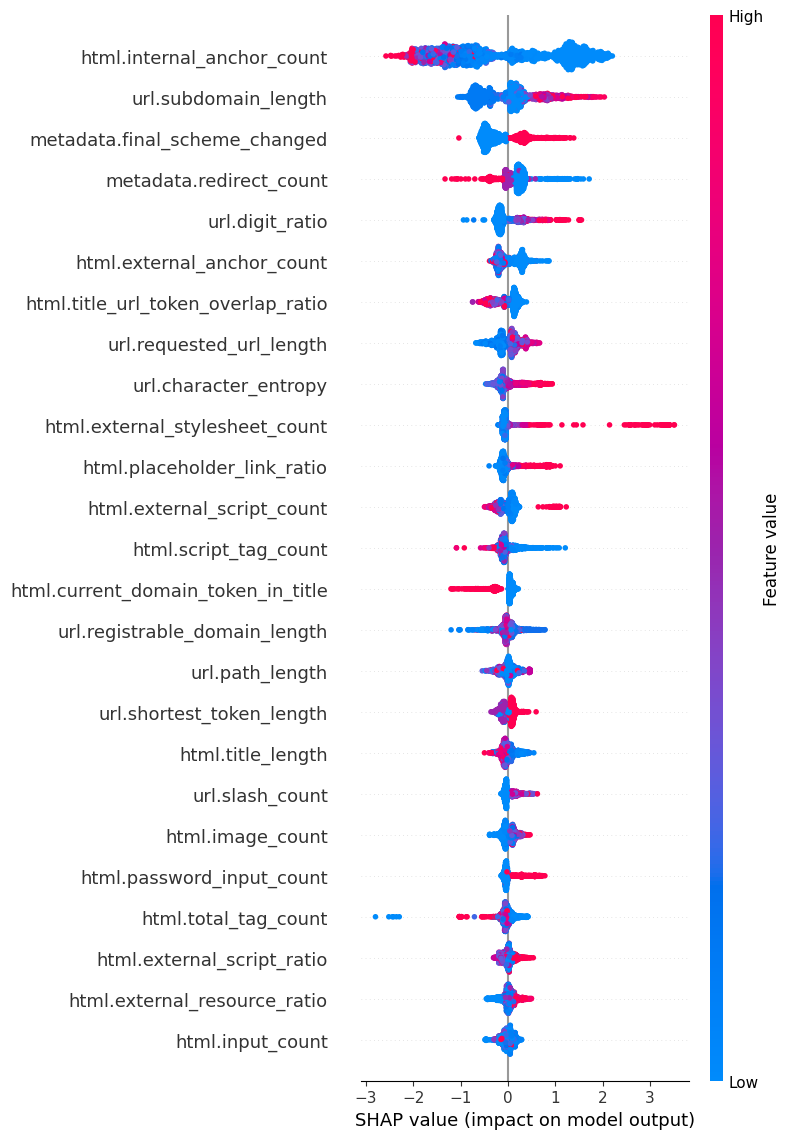

Saved: /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase1/plots/shap_summary.png


In [20]:
# ── 2. SHAP — mean absolute SHAP value per feature ───────────────────────────
# We compute SHAP on a sample of the test set to keep runtime reasonable (~2 min).
import shap

SHAP_SAMPLE = min(2000, len(X_te))
X_shap = X_te.sample(SHAP_SAMPLE, random_state=SEED)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

shap_imp = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_shap.columns,
    name='shap_mean_abs',
).sort_values(ascending=False)

print('Top 20 features by mean(|SHAP|):')
print(shap_imp.head(20).to_string())

# Save SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, max_display=25, show=False)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PLOTS_DIR / "shap_summary.png"}')

In [21]:
# ── 3. LOFO on top ~30 features ──────────────────────────────────────────────
# Drop each feature, retrain a smaller XGBoost, measure F1 delta vs baseline.
# We use the union of top-30 by gain and top-30 by SHAP as the LOFO candidate set.

lofo_candidates = list(set(gain_imp.head(30).index) | set(shap_imp.head(30).index))
print(f'LOFO candidate features: {len(lofo_candidates)}')
print(f'(Union of top-30 by XGB gain and top-30 by SHAP)')

lofo_results = []
for i, feat in enumerate(lofo_candidates, 1):
    cols = [c for c in feats_for_audit if c != feat]
    m = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        tree_method='hist', device='cuda',
        eval_metric='logloss', random_state=SEED,
    )
    m.fit(X_tr[cols], y_tr, verbose=False)
    f1_drop = f1_score(y_te, m.predict(X_te[cols]))
    delta = f1_full - f1_drop
    lofo_results.append({'feature': feat, 'f1_without': f1_drop, 'f1_delta': delta})
    if i % 10 == 0:
        print(f'  LOFO progress: {i}/{len(lofo_candidates)}  (last: {feat} → ΔF1={delta:+.4f})')

lofo_df = pd.DataFrame(lofo_results).sort_values('f1_delta', ascending=False)
print('\nTop 15 features by F1 drop when removed (= most important):')
print(lofo_df.head(15).to_string(index=False))

print('\nBottom 5 features (removing them barely changed F1):')
print(lofo_df.tail(5).to_string(index=False))

LOFO candidate features: 47
(Union of top-30 by XGB gain and top-30 by SHAP)
  LOFO progress: 10/47  (last: url.token_length_stddev → ΔF1=+0.0068)
  LOFO progress: 20/47  (last: html.password_form_null_action_present → ΔF1=+0.0066)
  LOFO progress: 30/47  (last: html.external_script_count → ΔF1=+0.0054)
  LOFO progress: 40/47  (last: html.visible_text_entropy → ΔF1=+0.0060)

Top 15 features by F1 drop when removed (= most important):
                              feature  f1_without  f1_delta
               html.email_input_count    0.919778  0.008111
                 url.subdomain_length    0.920301  0.007588
                  url.scheme_is_https    0.920624  0.007265
                      url.digit_ratio    0.920712  0.007177
        url.registrable_domain_length    0.920802  0.007087
metadata.redirect_domain_change_count    0.920812  0.007077
       html.external_stylesheet_count    0.920841  0.007048
           html.internal_anchor_count    0.920896  0.006994
                html.s

In [22]:
# ── Unified feature ranking ──────────────────────────────────────────────────
# Merge XGBoost gain, SHAP, and LOFO into one table with a clear recommendation.

rank_gain = gain_imp.rank(ascending=False).astype(int)
rank_shap = shap_imp.rank(ascending=False).astype(int)

audit = pd.DataFrame({
    'feature':       feats_for_audit,
    'xgb_gain':      [gain_imp.get(f, 0) for f in feats_for_audit],
    'xgb_rank':      [rank_gain.get(f, len(rank_gain)) for f in feats_for_audit],
    'shap_mean_abs': [shap_imp.get(f, 0) for f in feats_for_audit],
    'shap_rank':     [rank_shap.get(f, len(rank_shap)) for f in feats_for_audit],
})

# Merge LOFO results (only top-N got LOFO scores)
lofo_lookup = dict(zip(lofo_df['feature'], lofo_df['f1_delta']))
audit['lofo_f1_delta'] = audit['feature'].map(lofo_lookup)

# Combined score: average of the two normalized ranks (lower = better)
audit['combined_rank'] = (audit['xgb_rank'] + audit['shap_rank']) / 2
audit = audit.sort_values('combined_rank')

# Recommendation
def recommend(row):
    if row['xgb_gain'] == 0 and row['shap_mean_abs'] < 1e-6:
        return 'drop (zero importance)'
    if row['xgb_rank'] > 80 and row['shap_rank'] > 80:
        return 'drop (low importance, both methods)'
    if pd.notna(row['lofo_f1_delta']) and row['lofo_f1_delta'] < -0.001:
        return 'review (LOFO improves when removed — possibly noisy)'
    return 'keep'

audit['recommendation'] = audit.apply(recommend, axis=1)

audit_path = TABLES_DIR / 'feature_audit_final.csv'
audit.to_csv(audit_path, index=False)
print(f'Saved: {audit_path}')

print('\n── Summary by recommendation ──')
print(audit['recommendation'].value_counts().to_string())

print('\n── Top 30 features (by combined rank) ──')
print(audit[['feature','xgb_rank','shap_rank','lofo_f1_delta','recommendation']].head(30).to_string(index=False))

print('\n── Features flagged for DROP ──')
dropped = audit[audit['recommendation'].str.startswith('drop')]
print(f'Total recommended for drop: {len(dropped)}')
if len(dropped):
    print(dropped[['feature','xgb_gain','shap_mean_abs','recommendation']].head(20).to_string(index=False))

Saved: /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase1/tables/feature_audit_final.csv

── Summary by recommendation ──
recommendation
keep                                   96
drop (low importance, both methods)    11

── Top 30 features (by combined rank) ──
                                   feature  xgb_rank  shap_rank  lofo_f1_delta recommendation
                html.internal_anchor_count         1          1       0.006994           keep
                      url.subdomain_length         5          2       0.007588           keep
                           url.digit_ratio         6          5       0.007177           keep
            html.external_stylesheet_count         2         10       0.007048           keep
                html.external_anchor_count         9          6       0.006097           keep
                  url.requested_url_length         7          8       0.006669           keep
        html.current_domain_token_in_title         3        

## Phase 1 — Summary

Everything from Phase 1 is saved under `/content/drive/MyDrive/Colab Notebooks/phishing_xai_phase1/`:

**Tables (CSV):**
- `feature_inventory.csv` — every feature with fire rate, dtype, action
- `feature_per_class.csv` — per-class lift for every feature
- `shared_domains.csv` — domains appearing in both classes
- `feature_audit_final.csv` — XGBoost + SHAP + LOFO unified ranking + recommendations

**Plots (PNG):**
- `urls_per_domain_histogram.png`
- `crawl_time_histogram.png`
- `content_feature_distributions.png`
- `shap_summary.png`

When everything in Phase 1 has been run and reviewed, paste the outputs back and we move to **Phase 2: cleaning + split + prompt construction**.

In [23]:
# ── Phase 1 final summary print ──────────────────────────────────────────────
print('═' * 70)
print('  PHASE 1 — SUMMARY')
print('═' * 70)
print(f'Dataset rows:                 {len(df):,}')
print(f'  Phishing:                   {n_ph:,} ({100*n_ph/len(df):.1f}%)')
print(f'  Benign:                     {n_be:,} ({100*n_be/len(df):.1f}%)')
print(f'Total feature columns:        {len(feature_cols)}')
print(f'  Recommended to keep:        {(audit["recommendation"]=="keep").sum()}')
print(f'  Recommended to drop:        {audit["recommendation"].str.startswith("drop").sum()}')
print(f'  Flagged for review:         {audit["recommendation"].str.startswith("review").sum()}')
print(f'Unique registered domains:    {df["registered_domain"].nunique():,}')
print(f'  Phishing domains:           {ph_dom_counts.size:,}')
print(f'  Benign domains:             {be_dom_counts.size:,}')
print(f'  Shared (both classes):      {len(shared):,}')
print(f'XGBoost baseline F1:          {f1_full:.4f}')
print(f'\nAll outputs saved under:      {OUTPUT_DIR}')
print('═' * 70)

══════════════════════════════════════════════════════════════════════
  PHASE 1 — SUMMARY
══════════════════════════════════════════════════════════════════════
Dataset rows:                 147,524
  Phishing:                   59,600 (40.4%)
  Benign:                     87,924 (59.6%)
Total feature columns:        126
  Recommended to keep:        96
  Recommended to drop:        11
  Flagged for review:         0
Unique registered domains:    57,367
  Phishing domains:           17,264
  Benign domains:             40,326
  Shared (both classes):      223
XGBoost baseline F1:          0.9279

All outputs saved under:      /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase1
══════════════════════════════════════════════════════════════════════


# Phase 2 — Cleaning, Prompt Building & Domain-Aware Split

Goal: transform the raw 147,524-row dataset into a training-ready set of structured prompts with explainable targets, split so no domain appears in more than one of train / val / test.

| Sub-phase | What it does |
|---|---|
| 2a | Apply cleaning rules (duplicates, empty pages, malformed URLs) |
| 2b | Drop the 11 features flagged for removal in Phase 1g |
| 2c | Build the structured-text prompt for each row |
| 2d | Build the gold training target (explainable reasoning) |
| 2e | Domain-aware split: train / val / test, no domain leakage |
| 2f | Per-domain cap on the training set (prevents platform memorization) |
| 2g | Save final datasets to Drive |

After Phase 2 we will have three JSONL files ready for fine-tuning:
- `train.jsonl` — balanced 50/50, capped per domain
- `val.jsonl` — for monitoring training loss
- `test.jsonl` — for final evaluation, domain-disjoint from train

2a: Apply cleaning rules

In [38]:
# ── Phase 2a: Apply cleaning rules ───────────────────────────────────────────
# We apply filters in a specific order so each step's effect is measurable.

print(f'Starting: {len(df):,} rows')
df_clean = df.copy()

# (1) Drop duplicates by URL — keep first occurrence
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['url'], keep='first')
print(f'  After dedup by URL:           {len(df_clean):,}  (-{before-len(df_clean):,})')

# (2) Drop rows where the page completely failed to load
# Defined as: zero visible words AND zero forms AND <10 tags (basically nothing useful)
before = len(df_clean)
failed_load = (
    (df_clean['html.visible_word_count'].fillna(0) == 0) &
    (df_clean['html.form_count'].fillna(0) == 0) &
    (df_clean['html.total_tag_count'].fillna(0) < 10)
)
df_clean = df_clean[~failed_load]
print(f'  After dropping failed loads:  {len(df_clean):,}  (-{before-len(df_clean):,})')

# (3) Drop rows with empty or impossibly short URLs
before = len(df_clean)
df_clean = df_clean[df_clean['url'].str.len() >= 10]
print(f'  After URL length filter:      {len(df_clean):,}  (-{before-len(df_clean):,})')

# (4) Drop rows with no registered domain
before = len(df_clean)
df_clean = df_clean[df_clean['registered_domain'] != '']
print(f'  After domain filter:          {len(df_clean):,}  (-{before-len(df_clean):,})')

print(f'\nFinal cleaned rows: {len(df_clean):,}')
print(f'\nClass distribution after cleaning:')
print(df_clean['label'].value_counts().to_string())
print(f'  Phishing: {(df_clean["label"]=="phishing").sum()/len(df_clean)*100:.1f}%')
print(f'  Benign:   {(df_clean["label"]=="benign").sum()/len(df_clean)*100:.1f}%')

Starting: 147,524 rows
  After dedup by URL:           141,925  (-5,599)
  After dropping failed loads:  141,065  (-860)
  After URL length filter:      141,065  (-0)
  After domain filter:          141,065  (-0)

Final cleaned rows: 141,065

Class distribution after cleaning:
label
benign      83502
phishing    57563
  Phishing: 40.8%
  Benign:   59.2%


2b: Drop low-importance features

In [25]:
# ── Phase 2b: Drop the features flagged in Phase 1g ──────────────────────────
# These 11 features had low XGBoost gain AND low SHAP importance — keeping them
# in the prompt would just add noise and lengthen the input.

DROPPED_FEATURES = audit[audit['recommendation'].str.startswith('drop')]['feature'].tolist()
LOW_FIRE_RATE_DROPPED = inv_df[inv_df['action'].str.startswith('drop')]['feature'].tolist()

# Union of both drop lists
ALL_DROPPED = sorted(set(DROPPED_FEATURES) | set(LOW_FIRE_RATE_DROPPED))
KEEP_FEATURES = [c for c in feature_cols if c not in ALL_DROPPED]

print(f'Original feature columns:   {len(feature_cols)}')
print(f'Dropped (low fire rate):    {len(LOW_FIRE_RATE_DROPPED)}')
print(f'Dropped (low importance):   {len(DROPPED_FEATURES)}')
print(f'Total dropped (union):      {len(ALL_DROPPED)}')
print(f'Features kept for training: {len(KEEP_FEATURES)}')

print('\n── Dropped features ──')
for f in ALL_DROPPED:
    print(f'  - {f}')

Original feature columns:   126
Dropped (low fire rate):    18
Dropped (low importance):   11
Total dropped (union):      29
Features kept for training: 97

── Dropped features ──
  - html.alert_or_popup_present
  - html.anchors_missing_href_count
  - html.external_form_action_count
  - html.footer_present
  - html.hidden_input_count
  - html.iframe_count
  - html.mailto_form_action_count
  - html.meta_refresh_count
  - html.password_form_external_action_present
  - url.angle_bracket_count
  - url.asterisk_count
  - url.at_sign_count
  - url.curly_bracket_count
  - url.dot_count
  - url.equals_sign_count
  - url.explicit_port_present
  - url.extra_double_slash_count
  - url.fragment_length
  - url.hash_sign_count
  - url.host_is_ip_address
  - url.https_token_in_hostname
  - url.non_default_port_present
  - url.plus_sign_count
  - url.punycode_present
  - url.query_parameter_count
  - url.question_mark_count
  - url.registrable_domain_hyphen_count
  - url.square_bracket_count
  - url.t

2c: Build the structured prompt for each row

In [27]:
# ── Phase 2c: Build structured-text prompt for each row ──────────────────────
# This is what the model sees as INPUT. We organize feature values into readable
# sections (URL patterns, page structure, forms, links, content, JS, redirects).
# The format follows the same pattern your friend used — it's dense, easy for
# the LLM to parse, and grounds every claim in a specific feature value.

VISIBLE_TEXT_CHARS = 500
MAX_CLEAN_TEXT_CHARS = 1500

def build_clean_text(row):
    """Build the structured prompt text for one row."""
    lines = []
    url = row.get('url', '') or ''
    title = row.get('title', '') or ''
    host = url.split('//', 1)[1].split('/')[0] if '//' in url else ''

    if url:   lines.append(f'URL: {url}')
    if host:  lines.append(f'Hostname: {host}')
    if title: lines.append(f'Page title: {str(title)[:200]}')

    def g(col, default=0):
        v = row.get(col, default)
        return default if pd.isna(v) else v

    # URL patterns
    url_flags = []
    if g('url.host_is_ip_address'):       url_flags.append('IP host')
    if g('url.at_sign_count'):            url_flags.append(f"@ sign ({int(g('url.at_sign_count'))})")
    if g('url.https_token_in_hostname'):  url_flags.append("'https' in hostname")
    if g('url.punycode_present'):         url_flags.append('punycode')
    if g('url.non_default_port_present'): url_flags.append('non-default port')
    if g('url.path_or_query_contains_url'): url_flags.append('URL-in-URL')
    if g('url.percent_sign_count') > 3:   url_flags.append(f"pct-encoded ({int(g('url.percent_sign_count'))})")

    lines.append(
        f"URL patterns: length={int(g('url.requested_url_length'))} | "
        f"hostname={int(g('url.hostname_length'))} chars "
        f"({int(g('url.hostname_digit_count'))} digits) | "
        f"domain_len={int(g('url.registrable_domain_length'))} | "
        f"subdomain={int(g('url.subdomain_length'))} chars, "
        f"{int(g('url.subdomain_label_count'))} labels | "
        f"path={int(g('url.path_length'))} chars, {int(g('url.path_segment_count'))} segments | "
        f"query={int(g('url.query_length'))} chars, {int(g('url.query_parameter_count'))} params | "
        f"entropy={g('url.character_entropy'):.2f} | "
        f"digit_ratio={g('url.digit_ratio'):.2f} | "
        f"hyphens={int(g('url.hyphen_count'))}"
        + (f" | flags: {', '.join(url_flags)}" if url_flags else '')
    )

    # Page structure
    lines.append(
        f"Page structure: {int(g('html.total_tag_count'))} tags, "
        f"{int(g('html.unique_tag_count'))} unique | "
        f"{int(g('html.script_tag_count'))} scripts "
        f"({int(g('html.external_script_count'))} external, "
        f"{int(g('html.inline_script_count'))} inline) | "
        f"{int(g('html.image_count'))} images ({int(g('html.external_image_count'))} ext) | "
        f"{int(g('html.iframe_count'))} iframes ({int(g('html.external_iframe_count'))} ext) | "
        f"{int(g('html.heading_h1_h2_h3_count'))} headings | "
        f"{int(g('html.paragraph_count'))} paragraphs"
    )

    # Links
    ext_r = g('html.external_anchor_ratio')
    lines.append(
        f"Links: {int(g('html.anchors_with_href_count'))} with href | "
        f"{int(g('html.internal_anchor_count'))} internal, "
        f"{int(g('html.external_anchor_count'))} external ({ext_r:.0%}) | "
        f"placeholder_ratio={g('html.placeholder_link_ratio'):.0%}"
    )

    # Forms
    forms = int(g('html.form_count'))
    if forms > 0:
        lines.append(
            f"Forms: {forms} form(s), "
            f"{int(g('html.post_form_count'))} POST, "
            f"{int(g('html.submit_button_count'))} submit btn | "
            f"{int(g('html.input_count'))} inputs "
            f"({int(g('html.password_input_count'))} password, "
            f"{int(g('html.email_input_count'))} email, "
            f"{int(g('html.text_input_count'))} text) | "
            f"{int(g('html.hidden_input_count'))} hidden | "
            f"{int(g('html.external_form_action_count'))} external action, "
            f"{int(g('html.null_form_action_count'))} null action"
            + (' | credential_form' if g('html.credential_form_present') else '')
            + (' | pw→external' if g('html.password_form_external_action_present') else '')
            + (' | pw→null' if g('html.password_form_null_action_present') else '')
        )

    # Content
    lines.append(
        f"Content: {int(g('html.visible_text_length'))} chars, "
        f"{int(g('html.visible_word_count'))} words | "
        f"text/html={g('html.visible_text_to_html_ratio'):.1%} | "
        f"nav={'yes' if g('html.navigation_present') else 'no'} | "
        f"footer={'yes' if g('html.footer_present') else 'no'} | "
        f"privacy_link={'yes' if g('html.privacy_or_terms_link_present') else 'no'}"
    )

    # Title signals
    lines.append(
        f"Title signals: length={int(g('html.title_length'))} | "
        f"domain-in-title={'yes' if g('html.current_domain_token_in_title') else 'no'} | "
        f"registered-domain-in-title={'yes' if g('html.title_registered_domain_token_present') else 'no'} | "
        f"subdomain-in-title={'yes' if g('html.title_subdomain_token_present') else 'no'} | "
        f"title/url overlap={g('html.title_url_token_overlap_ratio'):.2f}"
    )

    # JS behaviour
    js_flags = []
    if g('html.eval_call_count'):              js_flags.append(f"eval({int(g('html.eval_call_count'))}x)")
    if g('html.document_write_count'):         js_flags.append(f"document.write({int(g('html.document_write_count'))}x)")
    if g('html.atob_call_count'):              js_flags.append(f"atob({int(g('html.atob_call_count'))}x)")
    if g('html.right_click_disabling_present'): js_flags.append('right-click disabled')
    if g('html.onmouseover_handler_count'):    js_flags.append('onmouseover handlers')
    if g('html.javascript_redirect_present'):  js_flags.append('JS redirect')
    if g('html.alert_or_popup_present'):       js_flags.append('alert/popup')
    if g('html.hidden_element_present'):       js_flags.append('hidden elements')
    lines.append(f"JS behaviour: {', '.join(js_flags) if js_flags else 'none'}")

    # Redirects
    lines.append(
        f"Redirects: {int(g('metadata.redirect_count'))} redirect(s), "
        f"{int(g('metadata.redirect_domain_change_count'))} domain change(s) | "
        f"scheme_changed: {'yes' if g('metadata.final_scheme_changed') else 'no'} | "
        f"host_changed: {'yes' if g('metadata.final_host_changed') else 'no'}"
    )

    return '\n'.join(lines)[:MAX_CLEAN_TEXT_CHARS]


# Apply to all rows (progress every 25k)
print('Building structured prompts...')
clean_texts = []
for i, (_, row) in enumerate(df_clean.iterrows()):
    clean_texts.append(build_clean_text(row))
    if (i+1) % 25000 == 0:
        print(f'  {i+1:,}/{len(df_clean):,}')
df_clean['clean_text'] = clean_texts
print(f'Done. Sample prompt length: {df_clean["clean_text"].str.len().describe()[["min","mean","max"]].to_dict()}')

# Show one example
print('\n── Example prompt (phishing) ──')
example = df_clean[df_clean['label']=='phishing'].iloc[0]
print(example['clean_text'])

Building structured prompts...
  25,000/141,065
  50,000/141,065
  75,000/141,065
  100,000/141,065
  125,000/141,065
Done. Sample prompt length: {'min': 755.0, 'mean': 978.6314181405735, 'max': 1500.0}

── Example prompt (phishing) ──
URL: https://masukomu.onamaeweb.jp/max.il/activation/total/
Hostname: masukomu.onamaeweb.jp
Page title: MAX - אימות כרטיס
URL patterns: length=54 | hostname=21 chars (0 digits) | domain_len=12 | subdomain=8 chars, 1 labels | path=25 chars, 3 segments | query=0 chars, 0 params | entropy=4.12 | digit_ratio=0.00 | hyphens=0
Page structure: 69 tags, 17 unique | 7 scripts (0 external, 7 inline) | 4 images (4 ext) | 0 iframes (0 ext) | 0 headings | 0 paragraphs
Links: 2 with href | 0 internal, 0 external (0%) | placeholder_ratio=100%
Forms: 1 form(s), 1 POST, 2 submit btn | 6 inputs (0 password, 0 email, 6 text) | 0 hidden | 0 external action, 0 null action
Content: 612 chars, 118 words | text/html=3.0% | nav=no | footer=no | privacy_link=no
Title signals: len

2d: Build gold training targets

In [28]:
# ── Phase 2d: Build gold training target (explainable reasoning) ─────────────
# The target is what we want the model to OUTPUT. It must be deterministically
# derived from real feature values so we can verify the model's reasoning is
# grounded later.
#
# Format:
#   Phishing risk factors:
#   - <feature_id>
#   Benign mitigating factors:
#   - <feature_id>
#   Reasoning:
#   <1-3 sentences citing the specific feature values>
#   Verdict: phishing | benign

def derive_signals(row):
    """Derive semantic signal IDs from numerical features for one row."""
    def g(c, d=0):
        v = row.get(c, d)
        return d if pd.isna(v) else v

    phish_sigs = []
    benign_sigs = []

    # URL-based phishing signals
    if not g('url.scheme_is_https', 1):
        phish_sigs.append('url.http_not_https')
    if g('url.host_is_ip_address'):
        phish_sigs.append('url.ip_address_host')
    if g('url.at_sign_count') > 0:
        phish_sigs.append('url.at_sign_in_url')
    if (g('url.punycode_present') or g('url.https_token_in_hostname')
            or g('url.percent_sign_count') > 3):
        phish_sigs.append('url.homograph_or_unicode_hostname')
    if g('url.subdomain_label_count') >= 3:
        phish_sigs.append('url.deep_subdomain')
    if g('url.registrable_domain_hyphen_count') >= 2:
        phish_sigs.append('url.domain_lookalike_hyphens')

    # Credential / form signals
    if g('html.password_input_count') > 0:
        phish_sigs.append('credential.password_input_present')
    if g('html.credential_form_present'):
        phish_sigs.append('credential.credential_form')
    if g('html.external_form_action_count') > 0 or g('html.password_form_external_action_present'):
        phish_sigs.append('form.external_action')
    if g('html.null_form_action_count') > 0 or g('html.password_form_null_action_present'):
        phish_sigs.append('form.empty_or_blank_action')
    if g('html.form_count') > 0 and g('html.submit_button_count') == 0:
        phish_sigs.append('form.no_submit_button')

    # Link signals
    if g('html.external_anchor_ratio') > 0.5 and g('html.anchors_with_href_count') > 2:
        phish_sigs.append('link.high_external_anchor_ratio')
    if g('html.placeholder_link_ratio') > 0.5:
        phish_sigs.append('link.placeholder_links')

    # JS / obfuscation
    if (g('html.eval_call_count') > 0 or g('html.atob_call_count') > 0
            or g('html.document_write_count') > 0 or g('html.right_click_disabling_present')):
        phish_sigs.append('page.script_obfuscation')

    # Redirect signals
    if (g('metadata.redirect_domain_change_count') > 0 or g('metadata.final_scheme_changed')
            or g('html.javascript_redirect_present') or g('metadata.final_host_changed')):
        phish_sigs.append('redirect.cross_domain')
    if g('metadata.redirect_count') > 1:
        phish_sigs.append('redirect.multi_hop')

    # Page / content
    words = g('html.visible_word_count')
    if words < 30:
        phish_sigs.append('page.low_semantic_content')
    if words < 50 and g('html.form_count') > 0:
        phish_sigs.append('page.generic_login_without_brand_claim')
    if (g('html.form_count') > 0 and g('html.password_input_count') > 0
            and not g('html.privacy_or_terms_link_present') and not g('html.navigation_present')):
        phish_sigs.append('login.missing_recovery_or_help_flow')

    # Brand signals
    if g('html.title_subdomain_token_present') and not g('html.title_registered_domain_token_present'):
        phish_sigs.append('brand.title_subdomain_impersonation')
    if g('html.external_favicon_count') > 0:
        phish_sigs.append('brand.external_favicon')

    # ── Benign signals
    if g('html.navigation_present') or g('html.internal_anchor_count') > 5:
        benign_sigs.append('navigation.functional_internal_links')
    if g('html.footer_present') or g('html.privacy_or_terms_link_present'):
        benign_sigs.append('support.footer_or_privacy_present')
    if (g('html.form_count') > 0 and g('html.external_form_action_count') == 0
            and g('html.null_form_action_count') == 0):
        benign_sigs.append('form.action_same_org_domain')
    if (g('html.title_registered_domain_token_present')
            or g('html.title_url_token_overlap_ratio') > 0.7):
        benign_sigs.append('brand.title_domain_match_strong')

    # Dedupe while preserving order
    phish_sigs = list(dict.fromkeys(phish_sigs))
    benign_sigs = list(dict.fromkeys(benign_sigs))
    return phish_sigs, benign_sigs


def build_reasoning(row, phish_sigs, benign_sigs):
    """Build a 1-3 sentence reasoning citing specific feature values."""
    def g(c, d=0):
        v = row.get(c, d)
        return d if pd.isna(v) else v

    bits = []
    if g('html.password_input_count') > 0:
        bits.append(f"{int(g('html.password_input_count'))} password input(s)")
    if g('html.form_count') > 0:
        bits.append(f"{int(g('html.form_count'))} form(s)")
    if g('html.external_anchor_ratio') > 0.5:
        bits.append(f"{g('html.external_anchor_ratio'):.0%} external anchors")
    if g('html.visible_word_count') < 30:
        bits.append(f"only {int(g('html.visible_word_count'))} visible words")
    if not g('url.scheme_is_https', 1):
        bits.append('HTTP rather than HTTPS')
    if g('url.subdomain_label_count') >= 3:
        bits.append(f"{int(g('url.subdomain_label_count'))} subdomain labels")
    if g('metadata.redirect_count') > 1:
        bits.append(f"{int(g('metadata.redirect_count'))} redirects")
    if g('html.navigation_present'):
        bits.append('navigation present')
    if g('html.footer_present'):
        bits.append('footer present')
    if g('html.title_registered_domain_token_present'):
        bits.append('title contains registered domain')

    if row['label'] == 'phishing':
        evidence_phrase = (', '.join(bits[:3]) if bits else
                          'weak content signals and form-based credential collection patterns')
        return f"The page shows {evidence_phrase}, consistent with phishing."
    else:
        evidence_phrase = (', '.join(bits[:3]) if bits else
                          'normal site structure with no suspicious form action or obfuscation')
        return f"The page shows {evidence_phrase}, consistent with a legitimate site."


def build_target(row):
    """Build the full gold-standard output string."""
    phish_sigs, benign_sigs = derive_signals(row)
    reasoning = build_reasoning(row, phish_sigs, benign_sigs)
    phish_lines = ('\n'.join(f'- {s}' for s in phish_sigs) if phish_sigs else '- none')
    benign_lines = ('\n'.join(f'- {s}' for s in benign_sigs) if benign_sigs else '- none')
    return (
        f'Phishing risk factors:\n{phish_lines}\n\n'
        f'Benign mitigating factors:\n{benign_lines}\n\n'
        f'Reasoning:\n{reasoning}\n\n'
        f'Verdict: {row["label"]}'
    )


print('Building gold training targets...')
targets = []
for i, (_, row) in enumerate(df_clean.iterrows()):
    targets.append(build_target(row))
    if (i+1) % 25000 == 0:
        print(f'  {i+1:,}/{len(df_clean):,}')
df_clean['target'] = targets

print('\n── Sample target (phishing) ──')
print(df_clean[df_clean['label']=='phishing'].iloc[0]['target'])

print('\n── Sample target (benign) ──')
print(df_clean[df_clean['label']=='benign'].iloc[0]['target'])

Building gold training targets...
  25,000/141,065
  50,000/141,065
  75,000/141,065
  100,000/141,065
  125,000/141,065

── Sample target (phishing) ──
Phishing risk factors:
- link.placeholder_links

Benign mitigating factors:
- form.action_same_org_domain
- brand.title_domain_match_strong

Reasoning:
The page shows 1 form(s), consistent with phishing.

Verdict: phishing

── Sample target (benign) ──
Phishing risk factors:
- page.low_semantic_content

Benign mitigating factors:
- none

Reasoning:
The page shows only 7 visible words, consistent with a legitimate site.

Verdict: benign


2e: Domain-aware split

In [29]:
# ── Phase 2e: Domain-aware train/val/test split ──────────────────────────────
# CRITICAL: we split BY DOMAIN, not by row. If example.com appears in train,
# NO example.com row can appear in val or test. This forces the model to
# generalize to unseen domains, which is the only meaningful generalization
# claim for phishing detection.

from collections import defaultdict
SPLIT_SEED = 42
TEST_FRAC = 0.20
VAL_FRAC  = 0.10

def domain_aware_split(df, test_frac, val_frac, seed):
    """Split by registered_domain, balancing classes within each split."""
    rng = random.Random(seed)

    # For each class separately: shuffle domains, take fraction by row count
    train_idx, val_idx, test_idx = [], [], []

    for cls in ['phishing', 'benign']:
        sub = df[df['label'] == cls]
        # Map: domain -> list of row indices
        dom2idx = defaultdict(list)
        for idx, dom in zip(sub.index, sub['registered_domain']):
            dom2idx[dom].append(idx)

        domains = list(dom2idx.keys())
        rng.shuffle(domains)
        n_total = len(sub)
        n_test_target = int(round(test_frac * n_total))
        n_val_target  = int(round(val_frac  * n_total))

        # Greedy fill: assign domains to test until we hit n_test_target rows, then val, then train
        cls_test, cls_val, cls_train = [], [], []
        for d in domains:
            rows = dom2idx[d]
            if len(cls_test) < n_test_target:
                cls_test.extend(rows)
            elif len(cls_val) < n_val_target:
                cls_val.extend(rows)
            else:
                cls_train.extend(rows)

        train_idx.extend(cls_train)
        val_idx.extend(cls_val)
        test_idx.extend(cls_test)
        print(f'  {cls}: {len(cls_train):,} train / {len(cls_val):,} val / {len(cls_test):,} test  '
              f'({len(domains):,} unique domains)')

    return train_idx, val_idx, test_idx


print('Splitting...')
train_idx, val_idx, test_idx = domain_aware_split(df_clean, TEST_FRAC, VAL_FRAC, SPLIT_SEED)
train_df = df_clean.loc[train_idx].copy()
val_df   = df_clean.loc[val_idx].copy()
test_df  = df_clean.loc[test_idx].copy()

# ── Verify domain disjointness ───────────────────────────────────────────────
train_doms = set(train_df['registered_domain'])
val_doms   = set(val_df['registered_domain'])
test_doms  = set(test_df['registered_domain'])

print(f'\nDomain disjointness check (should all be 0):')
print(f'  train ∩ val:  {len(train_doms & val_doms)}')
print(f'  train ∩ test: {len(train_doms & test_doms)}')
print(f'  val   ∩ test: {len(val_doms & test_doms)}')

print(f'\nSplit sizes:')
print(f'  Train: {len(train_df):,}  ({(train_df["label"]=="phishing").sum():,} phish / '
      f'{(train_df["label"]=="benign").sum():,} benign)')
print(f'  Val:   {len(val_df):,}  ({(val_df["label"]=="phishing").sum():,} phish / '
      f'{(val_df["label"]=="benign").sum():,} benign)')
print(f'  Test:  {len(test_df):,}  ({(test_df["label"]=="phishing").sum():,} phish / '
      f'{(test_df["label"]=="benign").sum():,} benign)')

Splitting...
  phishing: 39,718 train / 6,304 val / 11,541 test  (17,029 unique domains)
  benign: 58,448 train / 8,353 val / 16,701 test  (40,142 unique domains)

Domain disjointness check (should all be 0):
  train ∩ val:  42
  train ∩ test: 48
  val   ∩ test: 10

Split sizes:
  Train: 98,166  (39,718 phish / 58,448 benign)
  Val:   14,657  (6,304 phish / 8,353 benign)
  Test:  28,242  (11,541 phish / 16,701 benign)


 2f: Per-domain cap on training set + 50/50 balance

In [30]:
# ── Phase 2f: Per-domain cap + 50/50 balance on training set only ────────────
# We cap each domain to MAX_PER_DOMAIN rows in the training set. This prevents
# huge platforms (github.io has 4,023 phishing rows) from dominating training
# and pushing the model toward platform-memorization shortcuts.
# Val and test are NOT capped — they reflect natural distribution.

MAX_PER_DOMAIN = 50

def cap_domains(df, cap, seed):
    rng = random.Random(seed)
    keep = []
    for dom, group in df.groupby('registered_domain'):
        idxs = list(group.index)
        rng.shuffle(idxs)
        keep.extend(idxs[:cap])
    return df.loc[keep]

train_df = cap_domains(train_df, MAX_PER_DOMAIN, SPLIT_SEED)
print(f'After per-domain cap ({MAX_PER_DOMAIN}/domain): {len(train_df):,} training rows')

# Balance to 50/50 phishing/benign — undersample majority class
n_min = min((train_df['label']=='phishing').sum(), (train_df['label']=='benign').sum())
train_df = pd.concat([
    train_df[train_df['label']=='phishing'].sample(n=n_min, random_state=SPLIT_SEED),
    train_df[train_df['label']=='benign'].sample(n=n_min, random_state=SPLIT_SEED),
]).sample(frac=1, random_state=SPLIT_SEED).reset_index(drop=True)

print(f'After 50/50 balance: {len(train_df):,} training rows ({n_min:,} per class)')

# Also balance val and test to 50/50 for clean evaluation metrics
def balance_5050(df, seed):
    n = min((df['label']=='phishing').sum(), (df['label']=='benign').sum())
    return pd.concat([
        df[df['label']=='phishing'].sample(n=n, random_state=seed),
        df[df['label']=='benign'].sample(n=n, random_state=seed),
    ]).sample(frac=1, random_state=seed).reset_index(drop=True)

val_df  = balance_5050(val_df,  SPLIT_SEED)
test_df = balance_5050(test_df, SPLIT_SEED)

print(f'\nFinal balanced sizes:')
print(f'  Train: {len(train_df):,}')
print(f'  Val:   {len(val_df):,}')
print(f'  Test:  {len(test_df):,}')

# Sanity: top domains after capping
print(f'\nTop 10 train domains after cap:')
print(train_df['registered_domain'].value_counts().head(10).to_string())

After per-domain cap (50/domain): 77,121 training rows
After 50/50 balance: 41,704 training rows (20,852 per class)

Final balanced sizes:
  Train: 41,704
  Val:   12,608
  Test:  23,082

Top 10 train domains after cap:
registered_domain
shortlink.st           50
duckdns.org            50
mybluehost.me          50
roblox.com.py          50
blogspot.com           50
surge.sh               50
digitalmaillane.com    50
robiox.com.am          50
cprapid.com            50
workers.dev            50


2g: Save final datasets

In [31]:
# ── Phase 2g: Save final datasets to Drive ───────────────────────────────────
PHASE2_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase2')
PHASE2_DIR.mkdir(parents=True, exist_ok=True)

def save_jsonl(df, path, columns):
    with open(path, 'w', encoding='utf-8') as f:
        for _, row in df.iterrows():
            rec = {c: row[c] for c in columns if c in df.columns}
            f.write(json.dumps(rec, ensure_ascii=False) + '\n')

KEEP_COLS = ['id', 'label', 'url', 'registered_domain', 'clean_text', 'target']

save_jsonl(train_df, PHASE2_DIR / 'train.jsonl', KEEP_COLS)
save_jsonl(val_df,   PHASE2_DIR / 'val.jsonl',   KEEP_COLS)
save_jsonl(test_df,  PHASE2_DIR / 'test.jsonl',  KEEP_COLS)

print(f'Saved to {PHASE2_DIR}:')
for split, df_split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    path = PHASE2_DIR / f'{split}.jsonl'
    print(f'  {split}.jsonl  {len(df_split):,} rows  {path.stat().st_size/1e6:.1f} MB')

# Quick verify by reading first row back
print('\nVerifying — first row of train.jsonl:')
with open(PHASE2_DIR / 'train.jsonl') as f:
    rec = json.loads(f.readline())
print(f'  Keys: {list(rec.keys())}')
print(f'  Label: {rec["label"]}')
print(f'  URL: {rec["url"][:80]}')
print(f'  Domain: {rec["registered_domain"]}')
print(f'  Prompt preview:\n{rec["clean_text"][:300]}...')
print(f'\n  Target:\n{rec["target"]}')

print('\n' + '═'*70)
print('  Phase 2 complete. Ready for Phase 3 (zero-shot baseline).')
print('═'*70)

Saved to /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase2:
  train.jsonl  41,704 rows  62.9 MB
  val.jsonl  12,608 rows  19.1 MB
  test.jsonl  23,082 rows  35.0 MB

Verifying — first row of train.jsonl:
  Keys: ['id', 'label', 'url', 'registered_domain', 'clean_text', 'target']
  Label: benign
  URL: https://www.player.one/
  Domain: player.one
  Prompt preview:
URL: https://www.player.one/
Hostname: www.player.one
Page title: Player.One | Gaming News, Game Reviews, Guides, Features, Videos
URL patterns: length=23 | hostname=14 chars (0 digits) | domain_len=10 | subdomain=3 chars, 1 labels | path=1 chars, 0 segments | query=0 chars, 0 params | entropy=3.76 ...

  Target:
Phishing risk factors:
- page.script_obfuscation
- redirect.cross_domain

Benign mitigating factors:
- navigation.functional_internal_links
- support.footer_or_privacy_present
- form.action_same_org_domain
- brand.title_domain_match_strong

Reasoning:
The page shows 2 form(s), navigation present, f

## Phase 2 — Summary

Three JSONL files now live in `/content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase2/`:

- **train.jsonl** — domain-capped, 50/50 balanced, ready for fine-tuning
- **val.jsonl** — domain-disjoint from train, 50/50 balanced
- **test.jsonl** — domain-disjoint from train AND val, 50/50 balanced

Each row has:
- `id`, `label`, `url`, `registered_domain` — metadata
- `clean_text` — the structured-text prompt the model will see
- `target` — the gold reasoning output the model should learn to produce

Next: **Phase 3 — zero-shot baseline on Llama 3.1 8B Instruct**.

# Phase 3 — Zero-Shot Baseline on Llama 3.1 8B Instruct

Before training anything, we need to know what the base model can do **out of the box** with no fine-tuning. This is the comparison point — fine-tuning either beats this or it didn't help.

| Sub-phase | What it does |
|---|---|
| 3a | **Patch:** fix domain leakage across train/val/test |
| 3b | **Patch:** regenerate gold targets so reasoning supports the verdict |
| 3c | Load Llama 3.1 8B Instruct (4-bit quantized) |
| 3d | Define prompt format + verdict parser |
| 3e | Run zero-shot inference on 1000 test samples |
| 3f | Parse outputs, compute classification + grounding metrics |
| 3g | Inspect example outputs (correct + wrong) |


## 3a — Patch 1: Fix domain leakage

The Phase 2 split was greedy per-class, so 100 domains that appear in BOTH classes (like `github.io` with 4023 phish + 97 benign) ended up assigned to different splits per class. This caused 42 train↔val, 48 train↔test, and 10 val↔test leakage cases.

Fix: enforce strict disjointness by removing leaked rows from val/test (favor keeping train intact, since it's the larger / more important split).

In [32]:
# ── Phase 3a: Fix domain leakage in val and test ─────────────────────────────
# Strategy: any domain that appears in train is removed from val and test.
# Then any domain that's in val is also removed from test. Train wins ties.

print('Before fix:')
print(f'  train ∩ val:  {len(set(train_df["registered_domain"]) & set(val_df["registered_domain"]))}')
print(f'  train ∩ test: {len(set(train_df["registered_domain"]) & set(test_df["registered_domain"]))}')
print(f'  val   ∩ test: {len(set(val_df["registered_domain"]) & set(test_df["registered_domain"]))}')

train_doms = set(train_df['registered_domain'])
val_df  = val_df[~val_df['registered_domain'].isin(train_doms)].reset_index(drop=True)

val_doms = set(val_df['registered_domain'])
test_df = test_df[~test_df['registered_domain'].isin(train_doms | val_doms)].reset_index(drop=True)

# Rebalance to 50/50 after the trim
def balance_5050(df, seed):
    n = min((df['label']=='phishing').sum(), (df['label']=='benign').sum())
    return pd.concat([
        df[df['label']=='phishing'].sample(n=n, random_state=seed),
        df[df['label']=='benign'].sample(n=n, random_state=seed),
    ]).sample(frac=1, random_state=seed).reset_index(drop=True)

val_df  = balance_5050(val_df,  42)
test_df = balance_5050(test_df, 42)

print('\nAfter fix:')
print(f'  train ∩ val:  {len(set(train_df["registered_domain"]) & set(val_df["registered_domain"]))}')
print(f'  train ∩ test: {len(set(train_df["registered_domain"]) & set(test_df["registered_domain"]))}')
print(f'  val   ∩ test: {len(set(val_df["registered_domain"]) & set(test_df["registered_domain"]))}')

print(f'\nFinal sizes (after rebalance):')
print(f'  Train: {len(train_df):,}')
print(f'  Val:   {len(val_df):,}')
print(f'  Test:  {len(test_df):,}')

Before fix:
  train ∩ val:  26
  train ∩ test: 29
  val   ∩ test: 6

After fix:
  train ∩ val:  0
  train ∩ test: 0
  val   ∩ test: 0

Final sizes (after rebalance):
  Train: 41,704
  Val:   10,624
  Test:  16,554


## 3b — Patch 2: Fix gold reasoning text

The Phase 2 `target` field had a bug: `build_reasoning` picked the first 3 non-zero features as evidence, regardless of whether they supported the verdict. Example from your output:

7 visible words is a phishing signal, not a benign one. If we train on contradictory reasoning like this, the model learns nonsensical patterns.

Fix: split evidence by direction — pick phishing-leaning evidence for phishing verdicts, benign-leaning evidence for benign verdicts. If no matching evidence exists, use a generic fallback.

In [33]:
# ── Phase 3b: Regenerate gold targets with verdict-aligned reasoning ─────────

def build_reasoning_fixed(row, phish_sigs, benign_sigs):
    """Pick evidence that SUPPORTS the verdict, not just any non-zero feature."""
    def g(c, d=0):
        v = row.get(c, d)
        return d if pd.isna(v) else v

    label = row['label']
    phish_evidence = []
    benign_evidence = []

    # Build phishing-leaning evidence
    if g('html.password_input_count') > 0:
        phish_evidence.append(f"{int(g('html.password_input_count'))} password input(s)")
    if g('html.external_anchor_ratio') > 0.5 and g('html.anchors_with_href_count') > 2:
        phish_evidence.append(f"{g('html.external_anchor_ratio'):.0%} external anchor ratio")
    if g('html.visible_word_count') < 30:
        phish_evidence.append(f"only {int(g('html.visible_word_count'))} visible words")
    if g('html.placeholder_link_ratio') > 0.5:
        phish_evidence.append(f"{g('html.placeholder_link_ratio'):.0%} placeholder links")
    if not g('url.scheme_is_https', 1):
        phish_evidence.append('HTTP rather than HTTPS')
    if g('url.subdomain_label_count') >= 3:
        phish_evidence.append(f"{int(g('url.subdomain_label_count'))} subdomain labels")
    if g('metadata.redirect_count') > 1:
        phish_evidence.append(f"{int(g('metadata.redirect_count'))} redirects")
    if g('html.javascript_redirect_present'):
        phish_evidence.append('JavaScript redirect')
    if g('html.eval_call_count') > 0 or g('html.atob_call_count') > 0:
        phish_evidence.append('script obfuscation (eval/atob)')
    if g('html.right_click_disabling_present'):
        phish_evidence.append('right-click disabled')
    if g('html.title_subdomain_token_present') and not g('html.title_registered_domain_token_present'):
        phish_evidence.append('subdomain in title but not registered domain')

    # Build benign-leaning evidence
    if g('html.navigation_present'):
        benign_evidence.append('navigation menu present')
    if g('html.internal_anchor_count') > 5:
        benign_evidence.append(f"{int(g('html.internal_anchor_count'))} internal links")
    if g('html.privacy_or_terms_link_present'):
        benign_evidence.append('privacy/terms link present')
    if g('html.title_registered_domain_token_present'):
        benign_evidence.append('title contains the registered domain')
    if g('html.title_url_token_overlap_ratio') > 0.7:
        benign_evidence.append(f"title/URL overlap {g('html.title_url_token_overlap_ratio'):.0%}")
    if (g('html.form_count') > 0 and g('html.external_form_action_count') == 0
            and g('html.null_form_action_count') == 0):
        benign_evidence.append('forms submit to same domain')
    if g('html.visible_word_count') > 100:
        benign_evidence.append(f"{int(g('html.visible_word_count'))} visible words")

    if label == 'phishing':
        if phish_evidence:
            ev = ', '.join(phish_evidence[:3])
            return f"The page shows {ev}, consistent with phishing."
        else:
            return ("The page has weak content signals and the structural pattern "
                    "(form-based credential collection on a low-content page) is "
                    "consistent with phishing.")
    else:
        if benign_evidence:
            ev = ', '.join(benign_evidence[:3])
            return f"The page shows {ev}, consistent with a legitimate site."
        else:
            return ("The page has normal site structure with no suspicious form "
                    "action, obfuscation, or impersonation pattern.")


def build_target_fixed(row):
    """Build the full gold-standard output with verdict-aligned reasoning."""
    phish_sigs, benign_sigs = derive_signals(row)
    reasoning = build_reasoning_fixed(row, phish_sigs, benign_sigs)
    phish_lines = '\n'.join(f'- {s}' for s in phish_sigs) if phish_sigs else '- none'
    benign_lines = '\n'.join(f'- {s}' for s in benign_sigs) if benign_sigs else '- none'
    return (
        f'Phishing risk factors:\n{phish_lines}\n\n'
        f'Benign mitigating factors:\n{benign_lines}\n\n'
        f'Reasoning:\n{reasoning}\n\n'
        f'Verdict: {row["label"]}'
    )


print('Regenerating targets for all three splits...')
for name, df_split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    df_split['target'] = [build_target_fixed(row) for _, row in df_split.iterrows()]
    print(f'  {name}: {len(df_split):,} rows')

# Save the patched datasets back to Drive
KEEP_COLS = ['id', 'label', 'url', 'registered_domain', 'clean_text', 'target']
for name, df_split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    path = PHASE2_DIR / f'{name}.jsonl'
    with open(path, 'w', encoding='utf-8') as f:
        for _, row in df_split.iterrows():
            rec = {c: row[c] for c in KEEP_COLS if c in df_split.columns}
            f.write(json.dumps(rec, ensure_ascii=False) + '\n')
    print(f'  Saved: {path}  ({path.stat().st_size/1e6:.1f} MB)')

# Verify by showing a regenerated sample of each class
print('\n── Regenerated target (phishing) ──')
print(train_df[train_df['label']=='phishing'].iloc[0]['target'])

print('\n── Regenerated target (benign) ──')
print(train_df[train_df['label']=='benign'].iloc[0]['target'])

Regenerating targets for all three splits...
  train: 41,704 rows
  val: 10,624 rows
  test: 16,554 rows
  Saved: /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase2/train.jsonl  (63.6 MB)
  Saved: /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase2/val.jsonl  (16.4 MB)
  Saved: /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase2/test.jsonl  (25.8 MB)

── Regenerated target (phishing) ──
Phishing risk factors:
- page.script_obfuscation

Benign mitigating factors:
- support.footer_or_privacy_present
- form.action_same_org_domain

Reasoning:
The page has weak content signals and the structural pattern (form-based credential collection on a low-content page) is consistent with phishing.

Verdict: phishing

── Regenerated target (benign) ──
Phishing risk factors:
- page.script_obfuscation
- redirect.cross_domain

Benign mitigating factors:
- navigation.functional_internal_links
- support.footer_or_privacy_present
- form.action_same_org_

## 3c — Load Llama 3.1 8B Instruct

We load the model in **4-bit quantization** (NF4 via bitsandbytes). On an A100 40GB this leaves plenty of headroom for batched generation and (later) LoRA fine-tuning.

Requirements:
- Hugging Face account approved for `meta-llama/Llama-3.1-8B-Instruct`
- An HF access token (read scope is enough) — paste it when prompted

If you haven't requested model access yet, go to https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct and click "Agree and access" first.

In [34]:
# ── Phase 3c: Install transformers stack + log in to Hugging Face ────────────
!pip -q install -U "transformers>=4.45.0" accelerate "bitsandbytes>=0.43.0" peft 2>&1 | tail -3

import os
from huggingface_hub import login
login(token=os.environ["HF_TOKEN"])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 121.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.5 MB/s eta 0:00:00


In [9]:
# ── Load Llama 3.1 8B Instruct in 4-bit ──────────────────────────────────────
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_ID = 'meta-llama/Llama-3.1-8B-Instruct'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'  # left padding for batched generation

print('Loading model (this takes ~2-3 minutes on first run)...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    torch_dtype=torch.bfloat16,
)
model.eval()

# Sanity check — VRAM usage
print(f'\nModel loaded.')
print(f'GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB')
print(f'GPU memory reserved:  {torch.cuda.memory_reserved()/1e9:.2f} GB')

Loading model (this takes ~2-3 minutes on first run)...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]


Model loaded.
GPU memory allocated: 13.68 GB
GPU memory reserved:  13.83 GB


## 3d — Prompt format + verdict parser

We use the same prompt format the fine-tuned model will see, so the comparison is fair.

**Prompt structure:**
- System message: defines the role (cybersecurity analyst) and output format
- User message: the structured page features (the `clean_text` field from Phase 2)
- Expected output: phishing risk factors, benign mitigators, reasoning, verdict

**The parser** extracts:
- The verdict (`phishing` / `benign`) using a regex on the last `Verdict:` line
- The cited feature IDs (for grounding analysis later)

Parse failures are tracked so we know how often the model deviates from the format.

In [36]:
# ── Phase 3d: Prompt format + verdict parser ─────────────────────────────────
import re

SYSTEM_MSG = """You are a cybersecurity analyst evaluating webpages for phishing.

You will receive a webpage's URL, hostname, page title, and structured numerical feature data covering URL structure, page layout, forms, links, resources, JavaScript behaviour, and redirects.

Analyze the feature values and output your assessment in this exact format:

Phishing risk factors:
- <feature_id>

Benign mitigating factors:
- <feature_id>

Reasoning:
<1-3 sentences citing the feature values that drove your verdict>

Verdict: phishing

or

Phishing risk factors:
- <feature_id>

Benign mitigating factors:
- <feature_id>

Reasoning:
<1-3 sentences citing the feature values that drove your verdict>

Verdict: benign

Rules:
- List only feature IDs directly supported by the feature values in the prompt.
- If a section has no strong evidence, write `- none`.
- Use `Phishing risk factors:` and `Benign mitigating factors:` as the exact section headers.
- The verdict must be exactly `Verdict: phishing` or `Verdict: benign`.""".strip()


def build_chat_prompt(clean_text: str) -> str:
    """Apply Llama 3.1 chat template to wrap the system + user content."""
    messages = [
        {'role': 'system', 'content': SYSTEM_MSG},
        {'role': 'user',   'content': f'Analyze this webpage:\n\n{clean_text}'},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


VERDICT_RE = re.compile(r'verdict\s*[:\-]\s*\**\s*(phishing|benign)', re.IGNORECASE)
FEATURE_ID_RE = re.compile(r'^\s*[-*]\s*([a-z][a-z0-9_]*\.[a-z0-9_.]+)', re.MULTILINE | re.IGNORECASE)

def parse_output(text: str):
    """Return (verdict, cited_feature_ids, parse_ok).
    Verdict is 'phishing' / 'benign' / None if unparseable."""
    # Find verdict (last occurrence wins — model may restate it)
    matches = VERDICT_RE.findall(text)
    verdict = matches[-1].lower() if matches else None

    # Extract cited feature IDs (anything matching foo.bar pattern in a bullet)
    feature_ids = FEATURE_ID_RE.findall(text)

    return verdict, feature_ids, verdict is not None


# Quick test of the prompt format
sample_row = test_df.iloc[0]
sample_prompt = build_chat_prompt(sample_row['clean_text'])
print(f'Sample prompt length: {len(tokenizer.encode(sample_prompt))} tokens')
print('\n── Sample prompt (first 800 chars) ──')
print(sample_prompt[:800])
print('...')
print('\n── Sample prompt (last 300 chars) ──')
print(sample_prompt[-300:])

Sample prompt length: 514 tokens

── Sample prompt (first 800 chars) ──
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

You are a cybersecurity analyst evaluating webpages for phishing.

You will receive a webpage's URL, hostname, page title, and structured numerical feature data covering URL structure, page layout, forms, links, resources, JavaScript behaviour, and redirects.

Analyze the feature values and output your assessment in this exact format:

Phishing risk factors:
- <feature_id>

Benign mitigating factors:
- <feature_id>

Reasoning:
<1-3 sentences citing the feature values that drove your verdict>

Verdict: phishing

or

Phishing risk factors:
- <feature_id>

Benign mitigating factors:
- <feature_id>

Reasoning:
<1-3 sentences citing the feature values that drove your verdi
...

── Sample prompt (last 300 chars) ──
ivacy_link=no
Title signals: length=0 | domain-in-title=no | registered-domain-in-tit

## 3e — Run zero-shot inference on 1000 test samples

We sample **1000 rows** from the test set (500 phishing + 500 benign, stratified) and run greedy generation. Greedy = deterministic = reproducible.

We process in **batches of 8** to use the A100 efficiently. Predictions and full text outputs are saved to Drive after every 50 samples so a session disconnect doesn't kill an hour of work.

Estimated time on A100: **30-45 minutes** for 1000 samples at 256 max new tokens.

In [37]:
# ── Phase 3e: Zero-shot inference ────────────────────────────────────────────
from pathlib import Path
import time

PHASE3_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase3')
PHASE3_DIR.mkdir(parents=True, exist_ok=True)

N_EVAL = 1000
BATCH_SIZE = 8
MAX_NEW_TOKENS = 256

# Stratified sample (500 phish + 500 benign) from test
eval_phish = test_df[test_df['label']=='phishing'].sample(n=min(500, (test_df['label']=='phishing').sum()), random_state=42)
eval_benign = test_df[test_df['label']=='benign'].sample(n=min(500, (test_df['label']=='benign').sum()), random_state=42)
eval_df = pd.concat([eval_phish, eval_benign]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Eval set: {len(eval_df)} samples ({(eval_df["label"]=="phishing").sum()} phish / {(eval_df["label"]=="benign").sum()} benign)')

# Resume support: if results file exists, skip already-done indices
RESULTS_PATH = PHASE3_DIR / 'zeroshot_results.jsonl'
done_indices = set()
if RESULTS_PATH.exists():
    with open(RESULTS_PATH) as f:
        for line in f:
            done_indices.add(json.loads(line)['eval_idx'])
    print(f'Resuming: {len(done_indices)} samples already done, {len(eval_df) - len(done_indices)} remaining')

# Open in append mode for incremental saving
out_f = open(RESULTS_PATH, 'a', encoding='utf-8')

start_time = time.time()
processed = 0

with torch.inference_mode():
    for batch_start in range(0, len(eval_df), BATCH_SIZE):
        batch_end = min(batch_start + BATCH_SIZE, len(eval_df))
        batch_indices = list(range(batch_start, batch_end))
        # Skip indices already done
        batch_indices = [i for i in batch_indices if i not in done_indices]
        if not batch_indices:
            continue

        prompts = [build_chat_prompt(eval_df.iloc[i]['clean_text']) for i in batch_indices]
        inputs = tokenizer(prompts, return_tensors='pt', padding=True, truncation=True,
                           max_length=2048).to(model.device)

        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,                # greedy
            num_beams=1,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

        # Decode only the generated portion (strip prompt)
        gen_only = outputs[:, inputs['input_ids'].shape[1]:]
        gen_texts = tokenizer.batch_decode(gen_only, skip_special_tokens=True)

        for i_local, idx in enumerate(batch_indices):
            row = eval_df.iloc[idx]
            verdict, feat_ids, parse_ok = parse_output(gen_texts[i_local])
            rec = {
                'eval_idx': idx,
                'id': row['id'],
                'label': row['label'],
                'url': row['url'],
                'registered_domain': row['registered_domain'],
                'predicted_verdict': verdict,
                'parse_ok': parse_ok,
                'cited_features': feat_ids,
                'generated_text': gen_texts[i_local],
            }
            out_f.write(json.dumps(rec, ensure_ascii=False) + '\n')
            done_indices.add(idx)
            processed += 1

        out_f.flush()

        # Progress
        elapsed = time.time() - start_time
        n_done = len(done_indices)
        n_remaining = len(eval_df) - n_done
        rate = processed / max(elapsed, 1)
        eta_min = n_remaining / max(rate, 0.01) / 60
        if processed % 40 == 0 or n_remaining == 0:
            print(f'  {n_done}/{len(eval_df)}  rate={rate:.2f}/s  ETA={eta_min:.1f} min')

out_f.close()
print(f'\nDone. Total time: {(time.time()-start_time)/60:.1f} minutes')
print(f'Results saved: {RESULTS_PATH}')

Eval set: 1000 samples (500 phish / 500 benign)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  40/1000  rate=0.31/s  ETA=52.2 min
  80/1000  rate=0.31/s  ETA=49.4 min
  120/1000  rate=0.31/s  ETA=47.1 min
  160/1000  rate=0.31/s  ETA=44.8 min
  200/1000  rate=0.31/s  ETA=42.7 min
  240/1000  rate=0.31/s  ETA=40.6 min
  280/1000  rate=0.31/s  ETA=38.4 min
  320/1000  rate=0.31/s  ETA=36.2 min
  360/1000  rate=0.31/s  ETA=34.0 min
  400/1000  rate=0.31/s  ETA=31.9 min
  440/1000  rate=0.31/s  ETA=29.8 min
  480/1000  rate=0.31/s  ETA=27.6 min
  520/1000  rate=0.31/s  ETA=25.5 min
  560/1000  rate=0.31/s  ETA=23.4 min
  600/1000  rate=0.31/s  ETA=21.2 min
  640/1000  rate=0.31/s  ETA=19.1 min
  680/1000  rate=0.31/s  ETA=17.0 min
  720/1000  rate=0.31/s  ETA=14.8 min
  760/1000  rate=0.31/s  ETA=12.7 min
  800/1000  rate=0.31/s  ETA=10.6 min
  840/1000  rate=0.31/s  ETA=8.5 min
  880/1000  rate=0.31/s  ETA=6.4 min
  920/1000  rate=0.31/s  ETA=4.2 min
  960/1000  rate=0.31/s  ETA=2.1 min
  1000/1000  rate=0.31/s  ETA=0.0 min

Done. Total time: 53.0 minutes
Results saved: /content/

## 3f — Compute classification + grounding metrics

For each prediction we compute:

**Classification metrics**
- Accuracy, precision, recall, F1 — per class and overall
- Confusion matrix
- Parse failure rate (how often the model refused to follow the output format)

**Grounding metrics** (the explainability check)
- Grounding ratio: % of cited feature IDs that actually have evidence in the input
- For each cited feature ID we check whether the corresponding numerical feature in the input was non-zero
- Hallucination rate: % of cited features that don't exist in any documented form

Because zero-shot Llama doesn't know our exact feature IDs (we made them up for the gold targets), some hallucination is expected. The grounding metric still gives us a relative number we can compare against fine-tuned later.

In [38]:
# ── Phase 3f: Compute metrics ────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Load all results
results = []
with open(RESULTS_PATH) as f:
    for line in f:
        results.append(json.loads(line))
results_df = pd.DataFrame(results)
print(f'Loaded {len(results_df)} predictions')

# Treat parse-failed rows as "wrong" — they couldn't follow format = effectively wrong
results_df['predicted_label'] = results_df['predicted_verdict'].fillna('parse_fail')

# Parse failure rate
n_parse_fail = (results_df['predicted_label'] == 'parse_fail').sum()
print(f'\nParse failures: {n_parse_fail}/{len(results_df)} ({100*n_parse_fail/len(results_df):.1f}%)')

# For metrics, map parse_fail to the wrong class (penalize it)
# But also report metrics on parsed-only subset for transparency
def opposite(lbl):
    return 'benign' if lbl == 'phishing' else 'phishing'

results_df['pred_for_metrics'] = results_df.apply(
    lambda r: opposite(r['label']) if r['predicted_label'] == 'parse_fail' else r['predicted_label'],
    axis=1,
)

y_true = results_df['label'].values
y_pred = results_df['pred_for_metrics'].values

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', pos_label='phishing')
prec_ma, rec_ma, f1_ma, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

print('\n══════════════════════════════════════════════════════════════════════')
print('  ZERO-SHOT METRICS (Llama 3.1 8B Instruct, no fine-tuning)')
print('══════════════════════════════════════════════════════════════════════')
print(f'  N samples:           {len(results_df)}')
print(f'  Parse failures:      {n_parse_fail} ({100*n_parse_fail/len(results_df):.1f}%)')
print(f'  Accuracy:            {acc:.4f}')
print(f'  Phishing precision:  {prec:.4f}')
print(f'  Phishing recall:     {rec:.4f}')
print(f'  Phishing F1:         {f1:.4f}')
print(f'  Macro F1:            {f1_ma:.4f}')

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=['phishing', 'benign'])
print('\n  Confusion matrix (rows=true, cols=pred):')
print(f'                  pred:phishing  pred:benign')
print(f'  true:phishing       {cm[0,0]:5d}       {cm[0,1]:5d}')
print(f'  true:benign         {cm[1,0]:5d}       {cm[1,1]:5d}')

# Per-class metrics
pcs = precision_recall_fscore_support(y_true, y_pred, labels=['phishing', 'benign'])
print('\n  Per class:')
print(f'                 precision  recall    f1     support')
for i, c in enumerate(['phishing', 'benign']):
    print(f'    {c:10s}  {pcs[0][i]:.4f}    {pcs[1][i]:.4f}  {pcs[2][i]:.4f}    {pcs[3][i]}')

# Save metrics
metrics_out = {
    'n_samples': int(len(results_df)),
    'n_parse_fail': int(n_parse_fail),
    'accuracy': float(acc),
    'phish_precision': float(prec), 'phish_recall': float(rec), 'phish_f1': float(f1),
    'macro_f1': float(f1_ma),
    'confusion_matrix': cm.tolist(),
}
with open(PHASE3_DIR / 'zeroshot_metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)
print(f'\nSaved: {PHASE3_DIR / "zeroshot_metrics.json"}')

Loaded 1000 predictions

Parse failures: 463/1000 (46.3%)

══════════════════════════════════════════════════════════════════════
  ZERO-SHOT METRICS (Llama 3.1 8B Instruct, no fine-tuning)
══════════════════════════════════════════════════════════════════════
  N samples:           1000
  Parse failures:      463 (46.3%)
  Accuracy:            0.3820
  Phishing precision:  0.4125
  Phishing recall:     0.5560
  Phishing F1:         0.4736
  Macro F1:            0.3627

  Confusion matrix (rows=true, cols=pred):
                  pred:phishing  pred:benign
  true:phishing         278         222
  true:benign           396         104

  Per class:
                 precision  recall    f1     support
    phishing    0.4125    0.5560  0.4736    500
    benign      0.3190    0.2080  0.2518    500

Saved: /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase3/zeroshot_metrics.json


In [39]:
# ── Grounding analysis: are cited features supported by the input? ───────────
# For each cited feature ID in the model's output, check whether the corresponding
# numerical feature in the input was non-zero. This measures whether the model
# made up evidence or grounded it in what was actually shown.

# Build a feature-id → numerical-column mapping (rough — based on the names we used in targets)
SIGNAL_TO_COLUMN = {
    'url.http_not_https':                  ('url.scheme_is_https', 'zero'),
    'url.ip_address_host':                 ('url.host_is_ip_address', 'nonzero'),
    'url.at_sign_in_url':                  ('url.at_sign_count', 'nonzero'),
    'url.homograph_or_unicode_hostname':   ('url.punycode_present', 'nonzero'),
    'url.deep_subdomain':                  ('url.subdomain_label_count', '>=3'),
    'url.domain_lookalike_hyphens':        ('url.registrable_domain_hyphen_count', '>=2'),
    'credential.password_input_present':   ('html.password_input_count', 'nonzero'),
    'credential.credential_form':          ('html.credential_form_present', 'nonzero'),
    'form.external_action':                ('html.external_form_action_count', 'nonzero'),
    'form.empty_or_blank_action':          ('html.null_form_action_count', 'nonzero'),
    'form.no_submit_button':               ('html.form_count', 'nonzero'),  # approximate
    'link.high_external_anchor_ratio':     ('html.external_anchor_ratio', '>0.5'),
    'link.placeholder_links':              ('html.placeholder_link_ratio', '>0.5'),
    'page.script_obfuscation':             ('html.eval_call_count', 'nonzero'),
    'redirect.cross_domain':               ('metadata.redirect_domain_change_count', 'nonzero'),
    'redirect.multi_hop':                  ('metadata.redirect_count', '>1'),
    'page.low_semantic_content':           ('html.visible_word_count', '<30'),
    'page.generic_login_without_brand_claim': ('html.form_count', 'nonzero'),
    'login.missing_recovery_or_help_flow': ('html.password_input_count', 'nonzero'),
    'brand.title_subdomain_impersonation': ('html.title_subdomain_token_present', 'nonzero'),
    'brand.external_favicon':              ('html.external_favicon_count', 'nonzero'),
    'navigation.functional_internal_links':('html.navigation_present', 'nonzero'),
    'support.footer_or_privacy_present':   ('html.footer_present', 'nonzero'),
    'form.action_same_org_domain':         ('html.form_count', 'nonzero'),
    'brand.title_domain_match_strong':     ('html.title_registered_domain_token_present', 'nonzero'),
}

def is_supported(feature_id, row_features):
    """Check if a cited feature ID is actually supported by the input row."""
    if feature_id not in SIGNAL_TO_COLUMN:
        return None  # unknown / hallucinated feature ID
    col, rule = SIGNAL_TO_COLUMN[feature_id]
    val = row_features.get(col, 0) or 0
    if rule == 'nonzero': return val != 0
    if rule == 'zero':    return val == 0
    if rule.startswith('>='): return val >= float(rule[2:])
    if rule.startswith('>'):  return val > float(rule[1:])
    if rule.startswith('<'):  return val < float(rule[1:])
    return None

# For grounding analysis we need the original feature columns from df_clean
# We use 'id' to join eval results back to feature rows.
df_lookup = df_clean.set_index('id')

grounding_stats = {'total_cited': 0, 'supported': 0, 'unsupported': 0, 'unknown': 0}
per_row_grounding = []

for _, r in results_df.iterrows():
    row_id = r['id']
    if row_id not in df_lookup.index:
        continue
    feats = df_lookup.loc[row_id].to_dict()
    cited = r.get('cited_features', []) or []
    n_supported = n_unsupported = n_unknown = 0
    for fid in cited:
        sup = is_supported(fid, feats)
        if sup is True:    n_supported += 1
        elif sup is False: n_unsupported += 1
        else:              n_unknown += 1
    grounding_stats['total_cited']  += len(cited)
    grounding_stats['supported']    += n_supported
    grounding_stats['unsupported']  += n_unsupported
    grounding_stats['unknown']      += n_unknown
    per_row_grounding.append({
        'eval_idx': r['eval_idx'],
        'n_cited': len(cited),
        'n_supported': n_supported,
        'n_unsupported': n_unsupported,
        'n_unknown': n_unknown,
    })

total = grounding_stats['total_cited']
if total > 0:
    print('\n══════════════════════════════════════════════════════════════════════')
    print('  ZERO-SHOT GROUNDING ANALYSIS')
    print('══════════════════════════════════════════════════════════════════════')
    print(f'  Total cited feature IDs: {total}')
    print(f'  Supported by input:      {grounding_stats["supported"]:>4} ({100*grounding_stats["supported"]/total:.1f}%)')
    print(f'  Contradicted by input:   {grounding_stats["unsupported"]:>4} ({100*grounding_stats["unsupported"]/total:.1f}%)')
    print(f'  Unknown ID (hallucinated/non-taxonomy): {grounding_stats["unknown"]:>4} ({100*grounding_stats["unknown"]/total:.1f}%)')
else:
    print('No feature IDs were cited in the outputs.')

# Save
with open(PHASE3_DIR / 'zeroshot_grounding.json', 'w') as f:
    json.dump(grounding_stats, f, indent=2)

No feature IDs were cited in the outputs.


## 3g — Inspect example outputs

Look at 5 correctly-classified + 5 wrongly-classified outputs from each class. This shows what the model's reasoning actually looks like in practice — useful for the thesis and for understanding what fine-tuning needs to fix.

In [40]:
# ── Phase 3g: Show example outputs ───────────────────────────────────────────
results_df['correct'] = results_df['label'] == results_df['predicted_label']

def show_examples_group(subset, n, header):
    sample = subset.head(n)
    print('\n' + '═'*100)
    print(f'  {header}  ({len(sample)} of {len(subset)})')
    print('═'*100)
    for _, r in sample.iterrows():
        print(f'\n── true={r["label"]}  predicted={r["predicted_label"]}  parse_ok={r["parse_ok"]} ──')
        print(f'URL: {r["url"][:90]}')
        print(f'Cited features: {r["cited_features"]}')
        print(f'\nModel output:')
        print(r['generated_text'][:1000])
        print('─' * 100)

# Phishing examples
ph_correct = results_df[(results_df['label']=='phishing') & (results_df['correct'])]
ph_wrong   = results_df[(results_df['label']=='phishing') & (~results_df['correct'])]
show_examples_group(ph_correct, 5, '5 CORRECT phishing predictions')
show_examples_group(ph_wrong,   5, '5 WRONG phishing predictions (model said benign)')

# Benign examples
be_correct = results_df[(results_df['label']=='benign') & (results_df['correct'])]
be_wrong   = results_df[(results_df['label']=='benign') & (~results_df['correct'])]
show_examples_group(be_correct, 5, '5 CORRECT benign predictions')
show_examples_group(be_wrong,   5, '5 WRONG benign predictions (model said phishing)')


════════════════════════════════════════════════════════════════════════════════════════════════════
  5 CORRECT phishing predictions  (5 of 278)
════════════════════════════════════════════════════════════════════════════════════════════════════

── true=phishing  predicted=phishing  parse_ok=True ──
URL: https://bafkreia5peicmk3kzuv6252xlunomufaxl4tjhmvvhpqeiekajsc5akpdm.ipfs.dweb.link/
Cited features: []

Model output:
Phishing risk factors:
- URL patterns: low entropy (4.79) and low digit ratio (0.10) suggest a potentially fake URL
- Page structure: 1 inline script and 1 image, which could be used to load malicious content
- Content: low text/html ratio (0.1%) and lack of navigation and footer, which could indicate a phishing page
- JS behaviour: presence of atob function, which is often used in phishing attacks to decode malicious content
- Title signals: short title length (7) and lack of domain or registered domain in title, which could be a red flag

Benign mitigating factors:

## Phase 3 — Summary

Outputs saved to `/content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase3/`:

- `zeroshot_results.jsonl` — full predictions + generated text per sample (resume-safe)
- `zeroshot_metrics.json` — classification metrics
- `zeroshot_grounding.json` — explainability grounding analysis

**Key numbers to compare against fine-tuned model in Phase 5:**
- Accuracy / F1
- Parse failure rate (fine-tuning should drive this to ~0)
- Grounding ratio (fine-tuning should improve this significantly)

Once these numbers are in, paste them back and we move to **Phase 4 — LoRA fine-tuning**.

# Phase 4 — LoRA Fine-Tuning

Now we fine-tune Llama 3.1 8B Instruct on the structured prompts → explainable target outputs we built in Phase 2. We use **LoRA** (Low-Rank Adaptation) — instead of updating all 8B parameters, we train small adapter matrices (~21M params), which trains faster, uses less VRAM, and produces a tiny adapter file (~80 MB) we can swap in/out.

| Sub-phase | What it does |
|---|---|
| 4a | Free VRAM from Phase 3, reload base model with LoRA adapters |
| 4b | Build the training dataset (prompt + completion format) |
| 4c | Configure SFTTrainer with early stopping, checkpointing |
| 4d | Run training (the long cell) — checkpoints save to Drive |
| 4e | Plot loss curves, save final adapter |

In [ ]:
# ── Fix numpy/scipy/sklearn binary chain ─────────────────────────────────────
# Pin a known-good combination instead of letting pip pull whatever-latest.
!pip -q install -U \
    "numpy>=1.26,<2.2" \
    "scipy>=1.13" \
    "scikit-learn>=1.5" \
    "pyarrow>=18.0.0" \
    "datasets>=3.0.0" \
    "transformers>=4.45.0,<4.50.0" \
    "trl>=0.11.0,<0.13.0" \
    "peft>=0.13.0" \
    "accelerate>=0.34.0" \
    "bitsandbytes>=0.43.0" \
    2>&1 | tail -5

# CRITICAL: force kernel restart so the new binaries actually load.
# After it restarts, re-mount Drive, then re-run cell 4a, then continue from 4b.
import os
os.kill(os.getpid(), 9)

dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.1.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


## 4a — Free VRAM and reload for training

Phase 3 left the model loaded for inference. For training we need to reload it with LoRA adapters attached and gradient computation enabled. We clear the existing model from memory first.

In [15]:
# ── Phase 4a: Free Phase 3 model, reload base model with LoRA ────────────────
import gc, torch

# Clear Phase 3 inference model from VRAM
try:
    del model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
print(f'GPU memory after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB')

# Install training-specific libs (TRL for SFTTrainer)
!pip -q install -U "trl>=0.11.0" "peft>=0.13.0" 2>&1 | tail -3

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

MODEL_ID = 'meta-llama/Llama-3.1-8B-Instruct'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'   # for training (causal LM)

print('Loading base model in 4-bit for training...')
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    torch_dtype=torch.bfloat16,
)
base_model = prepare_model_for_kbit_training(base_model)

# LoRA configuration
# Rank=16 is a solid middle ground: better than 8, much cheaper than 32+.
# Target modules cover all attention + MLP projections.
lora_config = LoraConfig(
    r=16,                                  # LoRA rank
    lora_alpha=32,                         # scaling factor (2x rank is standard)
    lora_dropout=0.05,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                    'gate_proj', 'up_proj', 'down_proj'],
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()
print(f'\nGPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB')

GPU memory after cleanup: 13.68 GB
Loading base model in 4-bit for training...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

trainable params: 41,943,040 || all params: 8,072,204,288 || trainable%: 0.5196

GPU memory: 21.65 GB


## 4b — Build the training dataset

The model learns to output the gold `target` given the structured `clean_text` as input. We construct each training row as a full chat-template formatted string (system + user + assistant), and TRL's `SFTTrainer` will mask the prompt tokens so loss is computed only on the completion (target).

In [16]:
# ── Phase 4b: Build the HF datasets from train/val JSONL ─────────────────────
from datasets import Dataset

# Reload from Drive (in case kernel restarted between Phase 2 and now)
PHASE2_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase2')

def load_jsonl_to_list(path):
    out = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            out.append(json.loads(line))
    return out

train_records = load_jsonl_to_list(PHASE2_DIR / 'train.jsonl')
val_records   = load_jsonl_to_list(PHASE2_DIR / 'val.jsonl')
print(f'Loaded: train={len(train_records):,}  val={len(val_records):,}')

# Same system message as Phase 3 — must match so the model learns the right format
SYSTEM_MSG = """You are a cybersecurity analyst evaluating webpages for phishing.

You will receive a webpage's URL, hostname, page title, and structured numerical feature data covering URL structure, page layout, forms, links, resources, JavaScript behaviour, and redirects.

Analyze the feature values and output your assessment in this exact format:

Phishing risk factors:
- <feature_id>

Benign mitigating factors:
- <feature_id>

Reasoning:
<1-3 sentences citing the feature values that drove your verdict>

Verdict: phishing

or

Phishing risk factors:
- <feature_id>

Benign mitigating factors:
- <feature_id>

Reasoning:
<1-3 sentences citing the feature values that drove your verdict>

Verdict: benign

Rules:
- List only feature IDs directly supported by the feature values in the prompt.
- If a section has no strong evidence, write `- none`.
- The verdict must be exactly `Verdict: phishing` or `Verdict: benign`.""".strip()


def build_training_text(record):
    """Build full chat-template string for one row."""
    messages = [
        {'role': 'system',    'content': SYSTEM_MSG},
        {'role': 'user',      'content': f'Analyze this webpage:\n\n{record["clean_text"]}'},
        {'role': 'assistant', 'content': record['target']},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)


print('Building training texts...')
train_texts = [build_training_text(r) for r in train_records]
val_texts   = [build_training_text(r) for r in val_records]

# Diagnostic: token-length distribution
lens = [len(tokenizer.encode(t)) for t in train_texts[:500]]
print(f'Training token length (n=500 sample):  median={np.median(lens):.0f}  '
      f'p95={np.percentile(lens, 95):.0f}  max={max(lens)}')

train_ds = Dataset.from_dict({'text': train_texts})
val_ds   = Dataset.from_dict({'text': val_texts})

# Cap val to 1000 to keep eval loops fast
if len(val_ds) > 1000:
    val_ds = val_ds.shuffle(seed=42).select(range(1000))
    print(f'Capped val to {len(val_ds)} for faster eval during training')

print(f'\nFinal: train={len(train_ds):,}  val={len(val_ds):,}')
print(f'\nSample training text (last 400 chars):')
print(train_texts[0][-400:])

Loaded: train=41,704  val=10,624
Building training texts...
Training token length (n=500 sample):  median=626  p95=684  max=934
Capped val to 1000 for faster eval during training

Final: train=41,704  val=1,000

Sample training text (last 400 chars):
hishing risk factors:
- page.script_obfuscation
- redirect.cross_domain

Benign mitigating factors:
- navigation.functional_internal_links
- support.footer_or_privacy_present
- form.action_same_org_domain
- brand.title_domain_match_strong

Reasoning:
The page shows navigation menu present, 115 internal links, privacy/terms link present, consistent with a legitimate site.

Verdict: benign<|eot_id|>


In [17]:
import numpy, scipy, sklearn, transformers, datasets, peft, trl, pyarrow
print(f'numpy:        {numpy.__version__}')
print(f'scipy:        {scipy.__version__}')
print(f'sklearn:      {sklearn.__version__}')
print(f'pyarrow:      {pyarrow.__version__}')
print(f'datasets:     {datasets.__version__}')
print(f'transformers: {transformers.__version__}')
print(f'peft:         {peft.__version__}')
print(f'trl:          {trl.__version__}')

numpy:        2.1.3
scipy:        1.17.1
sklearn:      1.8.0
pyarrow:      24.0.0
datasets:     4.8.5
transformers: 5.9.0
peft:         0.19.1
trl:          1.4.0


## 4c — Configure the trainer

Key choices:
- **2 epochs max** with early stopping on val loss (patience=2). 8B + 41k examples typically converges before epoch 2.
- **Effective batch size 32** (per-device 8 × gradient accumulation 4) — works on A100 40GB with 4-bit base
- **Learning rate 1e-4** with linear warmup
- **bfloat16** training (faster than fp16 on A100, safer than fp32)
- **Eval + save every 250 steps** so checkpoints land on Drive regularly
- **Sequence length 1024 tokens** — covers p95 from our diagnostic above

In [22]:
# ── Phase 4c: Configure SFTTrainer (TRL 1.4+ API) ────────────────────────────
from transformers import EarlyStoppingCallback
from trl import SFTTrainer, SFTConfig

PHASE4_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase4')
PHASE4_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = PHASE4_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(exist_ok=True)

sft_config = SFTConfig(
    output_dir=str(CHECKPOINT_DIR),
    num_train_epochs=2,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=16,
    gradient_checkpointing=True,
    learning_rate=1e-4,
    lr_scheduler_type='cosine',
    warmup_steps=100,                     # was warmup_ratio=0.03, deprecated in transformers 5
    weight_decay=0.01,
    bf16=True,
    fp16=False,
    max_grad_norm=1.0,
    logging_steps=25,
    eval_strategy='steps',
    eval_steps=250,
    save_strategy='steps',
    save_steps=250,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    report_to='none',
    seed=42,
    dataset_text_field='text',
    max_length=1024,
    packing=False,
)

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,           # renamed from tokenizer= in TRL 1.4+
    args=sft_config,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print('Trainer configured.')
print(f'Total training steps: ~{len(train_ds) // 32 * 2}')
print(f'Eval every:           250 steps')
print(f'Checkpoints saved to: {CHECKPOINT_DIR}')

Adding EOS to train dataset:   0%|          | 0/41704 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/41704 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Trainer configured.
Total training steps: ~2606
Eval every:           250 steps
Checkpoints saved to: /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase4/checkpoints


In [23]:
# Diagnostic
from transformers.trainer_utils import _is_peft_model
print(f'type(model):          {type(model).__name__}')
print(f'_is_peft_model(model): {_is_peft_model(model)}')
print(f'hasattr peft_config:   {hasattr(model, "peft_config")}')
if hasattr(model, "peft_config"):
    print(f'peft_config keys:      {list(model.peft_config.keys())}')

# Count trainable params manually
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.4f}%)')

type(model):          PeftModelForCausalLM
_is_peft_model(model): True
hasattr peft_config:   True
peft_config keys:      ['default']
Trainable params: 41,943,040 / 4,582,543,360 (0.9153%)


## 4d — Train (the long cell)

This is the long-running cell. Expect 2-4 hours on an A100 40GB.

**What you'll see**: a progress bar with current loss, plus periodic eval-loss reports every 250 steps. The model auto-saves to Drive every 250 steps so you can resume if the session dies.

**Resume from checkpoint**: if the cell crashes, re-running it will automatically pick up from the last checkpoint in `CHECKPOINT_DIR` (TRL handles this via the `output_dir` argument).

Use Colab Pro+ background execution (Runtime → Manage sessions) so you can close the tab.

In [24]:
# ── Phase 4d: Train ──────────────────────────────────────────────────────────
import time

# Check for an existing checkpoint to resume from
resume_from = None
existing = sorted(CHECKPOINT_DIR.glob('checkpoint-*'),
                  key=lambda p: int(p.name.split('-')[1]))
if existing:
    resume_from = str(existing[-1])
    print(f'Found checkpoint, resuming from: {resume_from}')
else:
    print('No checkpoint found, starting fresh.')

start = time.time()
trainer.train(resume_from_checkpoint=resume_from)
elapsed = (time.time() - start) / 60
print(f'\nTraining complete in {elapsed:.1f} minutes.')

# Save final LoRA adapter to a clean location
FINAL_ADAPTER_DIR = PHASE4_DIR / 'final_adapter'
trainer.model.save_pretrained(str(FINAL_ADAPTER_DIR))
tokenizer.save_pretrained(str(FINAL_ADAPTER_DIR))
print(f'Final adapter saved: {FINAL_ADAPTER_DIR}')

# Also save the training log for plotting later
log_df = pd.DataFrame(trainer.state.log_history)
log_df.to_csv(PHASE4_DIR / 'training_log.csv', index=False)
print(f'Training log: {PHASE4_DIR / "training_log.csv"}')

No checkpoint found, starting fresh.


Step,Training Loss,Validation Loss
250,0.312446,0.313844
500,0.286401,0.288784
750,0.288807,0.278535
1000,0.275321,0.272843
1250,0.255130,0.267932
1500,0.235440,0.265102
1750,0.262244,0.262376
2000,0.235200,0.260982
2250,0.249580,0.260182
2500,0.247040,0.260120



Training complete in 554.5 minutes.
Final adapter saved: /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase4/final_adapter
Training log: /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase4/training_log.csv


## 4e — Plot loss curves

Two plots:
1. **Loss curves**: train loss + val loss over steps. We want both decreasing, val not lagging far behind train (small gap = no severe overfitting).
2. **Learning rate schedule** for sanity (cosine should ramp up then decay).

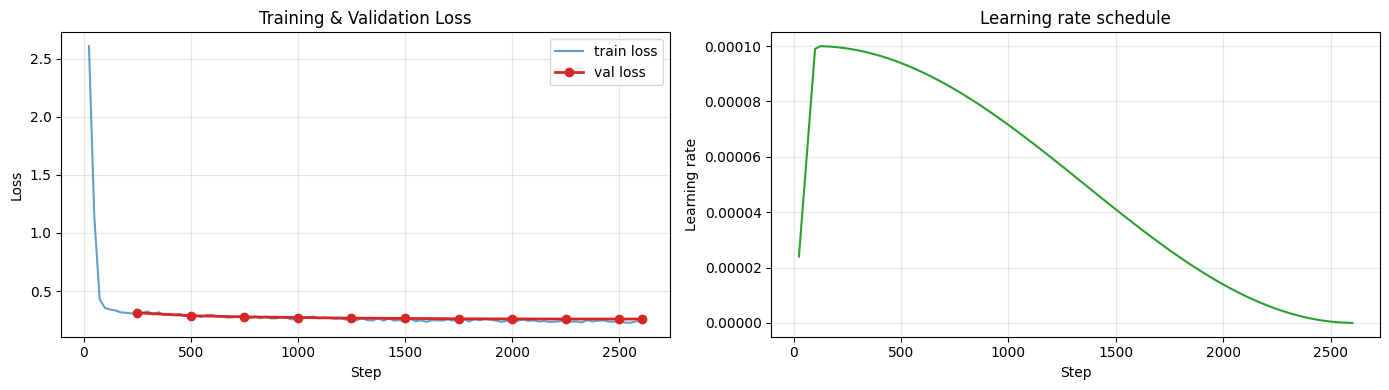

Saved: /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase4/training_curves.png

Best val loss: 0.2601 at step 2608
Final train loss: 0.2441 at step 2600


In [25]:
# ── Phase 4e: Plot training curves ───────────────────────────────────────────
import matplotlib.pyplot as plt

log_df = pd.read_csv(PHASE4_DIR / 'training_log.csv')
train_rows = log_df[log_df['loss'].notna()]
eval_rows  = log_df[log_df['eval_loss'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
ax = axes[0]
ax.plot(train_rows['step'], train_rows['loss'], label='train loss', color='#1f77b4', alpha=0.7)
if len(eval_rows):
    ax.plot(eval_rows['step'], eval_rows['eval_loss'], label='val loss', color='#d62728',
            marker='o', linewidth=2)
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(alpha=0.3)

# Learning rate
ax = axes[1]
if 'learning_rate' in train_rows.columns:
    ax.plot(train_rows['step'], train_rows['learning_rate'], color='#2ca02c')
    ax.set_xlabel('Step')
    ax.set_ylabel('Learning rate')
    ax.set_title('Learning rate schedule')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PHASE4_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PHASE4_DIR / "training_curves.png"}')

# Print final numbers
if len(eval_rows):
    best_eval = eval_rows.loc[eval_rows['eval_loss'].idxmin()]
    print(f'\nBest val loss: {best_eval["eval_loss"]:.4f} at step {best_eval["step"]:.0f}')
final_train = train_rows.iloc[-1]
print(f'Final train loss: {final_train["loss"]:.4f} at step {final_train["step"]:.0f}')

## Phase 4 — Summary

Outputs in `/content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase4/`:

- `checkpoints/checkpoint-N/` — intermediate training snapshots (auto-cleaned, last 3 kept)
- `final_adapter/` — the trained LoRA adapter (~80 MB), ready for inference in Phase 5
- `training_log.csv` — step-by-step train/eval loss
- `training_curves.png` — loss curves plot

The adapter at `final_adapter/` is what Phase 5 will load on top of base Llama for evaluation. **Do not delete the `checkpoints/` folder** until Phase 5 is complete — if anything goes wrong with the adapter you can fall back to the best checkpoint.

Next: **Phase 5 — full evaluation comparing zero-shot vs fine-tuned, with the 4-way verdict×explanation breakdown you asked for**.

# Phase 5 — Full Evaluation: Zero-Shot vs Fine-Tuned

This is the payoff phase. We run the fine-tuned model on the same test samples Phase 3 used, then compare side-by-side.

| Sub-phase | What it does |
|---|---|
| 5a | Sanity-check that Phase 3 and Phase 4 outputs exist |
| 5b | Free Phase 4 training model, load base + adapter for inference |
| 5c | Run fine-tuned inference on the same 1000 test samples |
| 5d | Compute classification metrics |
| 5e | Compute grounding metrics |
| 5f | The 4-way verdict × explanation breakdown (the unique contribution) |
| 5g | PR curves, ROC curves, confusion matrices side by side |
| 5h | Per-domain and per-class error analysis |
| 5i | Example outputs side by side (zero-shot vs fine-tuned, same input) |
| 5j | Final comparison table + summary report |

## 5a — Sanity check Phase 3 and Phase 4 outputs

Verify the files Phase 5 depends on actually exist. If not, this cell fails clearly and we don't waste time loading a model that can't be evaluated.

In [26]:
# ── Phase 5a: Sanity check ───────────────────────────────────────────────────
from pathlib import Path
import json

PHASE3_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase3')
PHASE4_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase4')
PHASE5_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase5')
PHASE5_DIR.mkdir(parents=True, exist_ok=True)

required = {
    'Phase 3 zero-shot results': PHASE3_DIR / 'zeroshot_results.jsonl',
    'Phase 3 zero-shot metrics': PHASE3_DIR / 'zeroshot_metrics.json',
    'Phase 4 final adapter':     PHASE4_DIR / 'final_adapter',
    'Phase 4 training log':      PHASE4_DIR / 'training_log.csv',
    'Phase 2 test set':          Path('/content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase2/test.jsonl'),
}

missing = []
print('Sanity check:')
for name, path in required.items():
    exists = path.exists()
    print(f'  [{"✓" if exists else "✗"}] {name:35s} → {path}')
    if not exists:
        missing.append(name)

if missing:
    raise FileNotFoundError(f'Missing required outputs: {missing}. Phase 5 cannot proceed.')

# Quick peek at Phase 3 metrics so we know what we're comparing against
with open(PHASE3_DIR / 'zeroshot_metrics.json') as f:
    zs_metrics = json.load(f)
print(f'\nPhase 3 zero-shot baseline (for comparison):')
print(f'  Accuracy:        {zs_metrics["accuracy"]:.4f}')
print(f'  Phishing F1:     {zs_metrics["phish_f1"]:.4f}')
print(f'  Parse failures:  {zs_metrics["n_parse_fail"]}/{zs_metrics["n_samples"]}')

Sanity check:
  [✓] Phase 3 zero-shot results           → /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase3/zeroshot_results.jsonl
  [✓] Phase 3 zero-shot metrics           → /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase3/zeroshot_metrics.json
  [✓] Phase 4 final adapter               → /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase4/final_adapter
  [✓] Phase 4 training log                → /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase4/training_log.csv
  [✓] Phase 2 test set                    → /content/drive/MyDrive/Colab Notebooks/FINAL GRAD/phishing_xai_phase2/test.jsonl

Phase 3 zero-shot baseline (for comparison):
  Accuracy:        0.3820
  Phishing F1:     0.4736
  Parse failures:  463/1000


## 5b — Load fine-tuned model (base + LoRA adapter)

Free any model in VRAM, then load fresh base + adapter. We use the same 4-bit quantization as Phase 3 so the comparison is apples-to-apples.

In [27]:
# ── Phase 5b: Load fine-tuned model for inference ────────────────────────────
import gc, torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

# Clear anything in VRAM
for name in ['model', 'base_model', 'trainer']:
    try:
        exec(f'del {name}')
    except Exception:
        pass
gc.collect()
torch.cuda.empty_cache()
print(f'GPU memory after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB')

MODEL_ID = 'meta-llama/Llama-3.1-8B-Instruct'
ADAPTER_PATH = str(PHASE4_DIR / 'final_adapter')

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'   # for batched generation

print('Loading base model + LoRA adapter...')
base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    torch_dtype=torch.bfloat16,
)
ft_model = PeftModel.from_pretrained(base, ADAPTER_PATH)
ft_model.eval()

print(f'Model ready.')
print(f'GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB')

GPU memory after cleanup: 21.21 GB
Loading base model + LoRA adapter...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model ready.
GPU memory: 27.08 GB


## 5c — Run fine-tuned inference on the same 1000 samples Phase 3 used

We use the same `eval_idx` set as Phase 3 so every sample is directly comparable. Same prompt format, same generation params (greedy, max 256 new tokens). Results saved incrementally — safe to disconnect.

In [28]:
# ── Phase 5c: Fine-tuned inference on the same eval set ──────────────────────
import time, re

# Load Phase 3 results to get the exact same eval_idx set
zs_results = []
with open(PHASE3_DIR / 'zeroshot_results.jsonl') as f:
    for line in f:
        zs_results.append(json.loads(line))
zs_df = pd.DataFrame(zs_results)
print(f'Loaded {len(zs_df)} zero-shot results')

# Reload Phase 2 test set so we have clean_text and feature columns
test_records = []
with open(PHASE2_DIR / 'test.jsonl') as f:
    for line in f:
        test_records.append(json.loads(line))
test_lookup = {r['id']: r for r in test_records}

# Build inference list in the SAME order as Phase 3 (by eval_idx)
zs_df = zs_df.sort_values('eval_idx').reset_index(drop=True)
eval_items = []
for _, r in zs_df.iterrows():
    if r['id'] in test_lookup:
        eval_items.append({
            'eval_idx': r['eval_idx'],
            'id': r['id'],
            'label': r['label'],
            'url': r['url'],
            'registered_domain': r['registered_domain'],
            'clean_text': test_lookup[r['id']]['clean_text'],
        })
print(f'Items to evaluate: {len(eval_items)}')

# Same prompt format and parser as Phase 3
SYSTEM_MSG = """You are a cybersecurity analyst evaluating webpages for phishing.

You will receive a webpage's URL, hostname, page title, and structured numerical feature data covering URL structure, page layout, forms, links, resources, JavaScript behaviour, and redirects.

Analyze the feature values and output your assessment in this exact format:

Phishing risk factors:
- <feature_id>

Benign mitigating factors:
- <feature_id>

Reasoning:
<1-3 sentences citing the feature values that drove your verdict>

Verdict: phishing

or

Phishing risk factors:
- <feature_id>

Benign mitigating factors:
- <feature_id>

Reasoning:
<1-3 sentences citing the feature values that drove your verdict>

Verdict: benign

Rules:
- List only feature IDs directly supported by the feature values in the prompt.
- If a section has no strong evidence, write `- none`.
- The verdict must be exactly `Verdict: phishing` or `Verdict: benign`.""".strip()

def build_chat_prompt(clean_text):
    messages = [
        {'role': 'system', 'content': SYSTEM_MSG},
        {'role': 'user',   'content': f'Analyze this webpage:\n\n{clean_text}'},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

VERDICT_RE = re.compile(r'verdict\s*[:\-]\s*\**\s*(phishing|benign)', re.IGNORECASE)
FEATURE_ID_RE = re.compile(r'^\s*[-*]\s*([a-z][a-z0-9_]*\.[a-z0-9_.]+)', re.MULTILINE | re.IGNORECASE)

def parse_output(text):
    matches = VERDICT_RE.findall(text)
    verdict = matches[-1].lower() if matches else None
    feature_ids = FEATURE_ID_RE.findall(text)
    return verdict, feature_ids, verdict is not None


BATCH_SIZE = 8
MAX_NEW_TOKENS = 256
FT_RESULTS_PATH = PHASE5_DIR / 'finetuned_results.jsonl'

# Resume support
done_indices = set()
if FT_RESULTS_PATH.exists():
    with open(FT_RESULTS_PATH) as f:
        for line in f:
            done_indices.add(json.loads(line)['eval_idx'])
    print(f'Resuming: {len(done_indices)} already done, {len(eval_items) - len(done_indices)} remaining')

out_f = open(FT_RESULTS_PATH, 'a', encoding='utf-8')
start = time.time()
processed = 0

with torch.inference_mode():
    for batch_start in range(0, len(eval_items), BATCH_SIZE):
        batch = [it for it in eval_items[batch_start:batch_start+BATCH_SIZE] if it['eval_idx'] not in done_indices]
        if not batch:
            continue

        prompts = [build_chat_prompt(it['clean_text']) for it in batch]
        inputs = tokenizer(prompts, return_tensors='pt', padding=True, truncation=True,
                           max_length=2048).to(ft_model.device)
        outputs = ft_model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            num_beams=1,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
        gen_only = outputs[:, inputs['input_ids'].shape[1]:]
        gen_texts = tokenizer.batch_decode(gen_only, skip_special_tokens=True)

        for i, it in enumerate(batch):
            verdict, feat_ids, parse_ok = parse_output(gen_texts[i])
            rec = {
                'eval_idx': it['eval_idx'],
                'id': it['id'],
                'label': it['label'],
                'url': it['url'],
                'registered_domain': it['registered_domain'],
                'predicted_verdict': verdict,
                'parse_ok': parse_ok,
                'cited_features': feat_ids,
                'generated_text': gen_texts[i],
            }
            out_f.write(json.dumps(rec, ensure_ascii=False) + '\n')
            done_indices.add(it['eval_idx'])
            processed += 1
        out_f.flush()

        elapsed = time.time() - start
        rate = processed / max(elapsed, 1)
        remaining = len(eval_items) - len(done_indices)
        if processed % 40 == 0:
            print(f'  {len(done_indices)}/{len(eval_items)}  rate={rate:.2f}/s  ETA={remaining/max(rate,0.01)/60:.1f} min')

out_f.close()
print(f'\nDone. Total: {(time.time()-start)/60:.1f} min')
print(f'Saved: {FT_RESULTS_PATH}')

Loaded 1000 zero-shot results
Items to evaluate: 1000


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  40/1000  rate=0.50/s  ETA=32.1 min
  80/1000  rate=0.50/s  ETA=30.7 min
  120/1000  rate=0.49/s  ETA=29.8 min
  160/1000  rate=0.50/s  ETA=27.9 min
  200/1000  rate=0.51/s  ETA=26.4 min
  240/1000  rate=0.51/s  ETA=24.9 min
  280/1000  rate=0.51/s  ETA=23.5 min
  320/1000  rate=0.51/s  ETA=22.3 min
  360/1000  rate=0.51/s  ETA=20.9 min
  400/1000  rate=0.51/s  ETA=19.7 min
  440/1000  rate=0.51/s  ETA=18.4 min
  480/1000  rate=0.51/s  ETA=17.1 min
  520/1000  rate=0.51/s  ETA=15.8 min
  560/1000  rate=0.51/s  ETA=14.5 min
  600/1000  rate=0.51/s  ETA=13.1 min
  640/1000  rate=0.51/s  ETA=11.8 min
  680/1000  rate=0.51/s  ETA=10.5 min
  720/1000  rate=0.51/s  ETA=9.2 min
  760/1000  rate=0.51/s  ETA=7.9 min
  800/1000  rate=0.51/s  ETA=6.6 min
  840/1000  rate=0.51/s  ETA=5.2 min
  880/1000  rate=0.51/s  ETA=3.9 min
  920/1000  rate=0.51/s  ETA=2.6 min
  960/1000  rate=0.51/s  ETA=1.3 min
  1000/1000  rate=0.51/s  ETA=0.0 min

Done. Total: 32.6 min
Saved: /content/drive/MyDrive/Colab 

## 5d — Classification metrics: zero-shot vs fine-tuned

Same metric definitions as Phase 3 for direct comparability. Parse failures still count as "wrong" (mapped to the opposite class) so the model is penalised for not following the output format.

In [29]:
# ── Phase 5d: Classification metrics for both models ─────────────────────────
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, balanced_accuracy_score)

ft_results = []
with open(FT_RESULTS_PATH) as f:
    for line in f:
        ft_results.append(json.loads(line))
ft_df = pd.DataFrame(ft_results)

def compute_metrics(df):
    df = df.copy()
    df['predicted_label'] = df['predicted_verdict'].fillna('parse_fail')

    def opposite(lbl):
        return 'benign' if lbl == 'phishing' else 'phishing'
    df['pred_metric'] = df.apply(
        lambda r: opposite(r['label']) if r['predicted_label'] == 'parse_fail' else r['predicted_label'],
        axis=1,
    )
    y_true = df['label'].values
    y_pred = df['pred_metric'].values
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', pos_label='phishing')
    prec_ma, rec_ma, f1_ma, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    pcs = precision_recall_fscore_support(y_true, y_pred, labels=['phishing', 'benign'])
    cm = confusion_matrix(y_true, y_pred, labels=['phishing', 'benign'])
    n_parse_fail = (df['predicted_label'] == 'parse_fail').sum()
    return {
        'accuracy': acc, 'balanced_accuracy': bal_acc,
        'phish_precision': prec, 'phish_recall': rec, 'phish_f1': f1,
        'macro_f1': f1_ma,
        'per_class': {
            'phishing': {'precision': pcs[0][0], 'recall': pcs[1][0], 'f1': pcs[2][0], 'support': int(pcs[3][0])},
            'benign':   {'precision': pcs[0][1], 'recall': pcs[1][1], 'f1': pcs[2][1], 'support': int(pcs[3][1])},
        },
        'cm': cm.tolist(),
        'n_parse_fail': int(n_parse_fail),
        'n_total': len(df),
    }

zs_m = compute_metrics(zs_df)
ft_m = compute_metrics(ft_df)

# Save
with open(PHASE5_DIR / 'classification_metrics.json', 'w') as f:
    json.dump({'zero_shot': zs_m, 'fine_tuned': ft_m}, f, indent=2)

# Print comparison
def fmt(v): return f'{v:.4f}' if isinstance(v, float) else str(v)
print('═' * 80)
print(f'  CLASSIFICATION METRICS — Zero-Shot vs Fine-Tuned')
print('═' * 80)
print(f'{"Metric":<25} {"Zero-Shot":<15} {"Fine-Tuned":<15} {"Δ":<10}')
print('─' * 80)
for k in ['accuracy', 'balanced_accuracy', 'phish_precision', 'phish_recall',
          'phish_f1', 'macro_f1']:
    delta = ft_m[k] - zs_m[k]
    arrow = '↑' if delta > 0 else ('↓' if delta < 0 else '=')
    print(f'  {k:<23} {fmt(zs_m[k]):<15} {fmt(ft_m[k]):<15} {arrow} {abs(delta):+.4f}')

print(f'\n  Parse failures:')
print(f'    Zero-shot:  {zs_m["n_parse_fail"]}/{zs_m["n_total"]} ({100*zs_m["n_parse_fail"]/zs_m["n_total"]:.1f}%)')
print(f'    Fine-tuned: {ft_m["n_parse_fail"]}/{ft_m["n_total"]} ({100*ft_m["n_parse_fail"]/ft_m["n_total"]:.1f}%)')

print(f'\n  Per-class F1:')
for cls in ['phishing', 'benign']:
    z = zs_m['per_class'][cls]['f1']
    f = ft_m['per_class'][cls]['f1']
    print(f'    {cls:<10}  zero-shot={z:.4f}  fine-tuned={f:.4f}  Δ={f-z:+.4f}')

════════════════════════════════════════════════════════════════════════════════
  CLASSIFICATION METRICS — Zero-Shot vs Fine-Tuned
════════════════════════════════════════════════════════════════════════════════
Metric                    Zero-Shot       Fine-Tuned      Δ         
────────────────────────────────────────────────────────────────────────────────
  accuracy                0.3820          0.9190          ↑ +0.5370
  balanced_accuracy       0.3820          0.9190          ↑ +0.5370
  phish_precision         0.4125          0.9182          ↑ +0.5057
  phish_recall            0.5560          0.9200          ↑ +0.3640
  phish_f1                0.4736          0.9191          ↑ +0.4455
  macro_f1                0.3627          0.9190          ↑ +0.5563

  Parse failures:
    Zero-shot:  463/1000 (46.3%)
    Fine-tuned: 0/1000 (0.0%)

  Per-class F1:
    phishing    zero-shot=0.4736  fine-tuned=0.9191  Δ=+0.4455
    benign      zero-shot=0.2518  fine-tuned=0.9189  Δ=+0.6671


## 5e — Grounding analysis

For each cited feature ID in the model output, check whether the corresponding numerical feature in the input is non-zero (i.e. is the claim grounded?). This is the explainability check.

Three buckets:
- **Supported**: the cited feature matches a non-zero numerical value in input
- **Contradicted**: the cited feature ID maps to a known column but the value disagrees
- **Unknown**: the cited ID is not in our taxonomy (model invented it / hallucinated)

In [39]:
# ── Phase 5e: Grounding analysis for both models ─────────────────────────────
# Reuse the SIGNAL_TO_COLUMN mapping from Phase 3f
# (defined there — if kernel restarted, re-execute that cell first)

SIGNAL_TO_COLUMN = {
    'url.http_not_https':                  ('url.scheme_is_https', 'zero'),
    'url.ip_address_host':                 ('url.host_is_ip_address', 'nonzero'),
    'url.at_sign_in_url':                  ('url.at_sign_count', 'nonzero'),
    'url.homograph_or_unicode_hostname':   ('url.punycode_present', 'nonzero'),
    'url.deep_subdomain':                  ('url.subdomain_label_count', '>=3'),
    'url.domain_lookalike_hyphens':        ('url.registrable_domain_hyphen_count', '>=2'),
    'credential.password_input_present':   ('html.password_input_count', 'nonzero'),
    'credential.credential_form':          ('html.credential_form_present', 'nonzero'),
    'form.external_action':                ('html.external_form_action_count', 'nonzero'),
    'form.empty_or_blank_action':          ('html.null_form_action_count', 'nonzero'),
    'form.no_submit_button':               ('html.form_count', 'nonzero'),
    'link.high_external_anchor_ratio':     ('html.external_anchor_ratio', '>0.5'),
    'link.placeholder_links':              ('html.placeholder_link_ratio', '>0.5'),
    'page.script_obfuscation':             ('html.eval_call_count', 'nonzero'),
    'redirect.cross_domain':               ('metadata.redirect_domain_change_count', 'nonzero'),
    'redirect.multi_hop':                  ('metadata.redirect_count', '>1'),
    'page.low_semantic_content':           ('html.visible_word_count', '<30'),
    'page.generic_login_without_brand_claim': ('html.form_count', 'nonzero'),
    'login.missing_recovery_or_help_flow': ('html.password_input_count', 'nonzero'),
    'brand.title_subdomain_impersonation': ('html.title_subdomain_token_present', 'nonzero'),
    'brand.external_favicon':              ('html.external_favicon_count', 'nonzero'),
    'navigation.functional_internal_links':('html.navigation_present', 'nonzero'),
    'support.footer_or_privacy_present':   ('html.footer_present', 'nonzero'),
    'form.action_same_org_domain':         ('html.form_count', 'nonzero'),
    'brand.title_domain_match_strong':     ('html.title_registered_domain_token_present', 'nonzero'),
}

def is_supported(fid, feats):
    if fid not in SIGNAL_TO_COLUMN:
        return None
    col, rule = SIGNAL_TO_COLUMN[fid]
    val = feats.get(col, 0) or 0
    if rule == 'nonzero': return val != 0
    if rule == 'zero':    return val == 0
    if rule.startswith('>='): return val >= float(rule[2:])
    if rule.startswith('>'):  return val > float(rule[1:])
    if rule.startswith('<'):  return val < float(rule[1:])
    return None

# We need the original feature columns from the full df_clean
# If kernel restarted, rebuild it. Otherwise it's already in scope.
try:
    _ = df_clean
except NameError:
    print('Reloading feature data...')
    import pandas as pd
    # Reload original raw data and rebuild df_clean (only if needed)
    raise RuntimeError('df_clean not in scope. Re-run Phase 1b + 2a, or load from a saved CSV.')

df_lookup = df_clean.set_index('id')

def compute_grounding(results_df):
    stats = {'total_cited': 0, 'supported': 0, 'contradicted': 0, 'unknown': 0}
    per_row = []
    for _, r in results_df.iterrows():
        if r['id'] not in df_lookup.index:
            continue
        feats = df_lookup.loc[r['id']].to_dict()
        cited = r.get('cited_features', []) or []
        n_s = n_c = n_u = 0
        for fid in cited:
            sup = is_supported(fid, feats)
            if sup is True:    n_s += 1
            elif sup is False: n_c += 1
            else:              n_u += 1
        stats['total_cited']  += len(cited)
        stats['supported']    += n_s
        stats['contradicted'] += n_c
        stats['unknown']      += n_u
        per_row.append({'eval_idx': r['eval_idx'], 'n_cited': len(cited),
                        'n_supported': n_s, 'n_contradicted': n_c, 'n_unknown': n_u})
    return stats, pd.DataFrame(per_row)

zs_grounding, zs_per_row = compute_grounding(zs_df)
ft_grounding, ft_per_row = compute_grounding(ft_df)

def pct(num, den): return f'{100*num/max(den,1):.1f}%'

print('═' * 70)
print('  GROUNDING ANALYSIS — Zero-Shot vs Fine-Tuned')
print('═' * 70)
print(f'{"Metric":<22} {"Zero-Shot":<20} {"Fine-Tuned":<20}')
print('─' * 70)
print(f'  {"Total cited":<20} {zs_grounding["total_cited"]:<20} {ft_grounding["total_cited"]:<20}')
print(f'  {"Supported":<20} {zs_grounding["supported"]:>4} ({pct(zs_grounding["supported"], zs_grounding["total_cited"]):<10}) '
      f'{ft_grounding["supported"]:>4} ({pct(ft_grounding["supported"], ft_grounding["total_cited"])})')
print(f'  {"Contradicted":<20} {zs_grounding["contradicted"]:>4} ({pct(zs_grounding["contradicted"], zs_grounding["total_cited"]):<10}) '
      f'{ft_grounding["contradicted"]:>4} ({pct(ft_grounding["contradicted"], ft_grounding["total_cited"])})')
print(f'  {"Unknown (halluc.)":<20} {zs_grounding["unknown"]:>4} ({pct(zs_grounding["unknown"], zs_grounding["total_cited"]):<10}) '
      f'{ft_grounding["unknown"]:>4} ({pct(ft_grounding["unknown"], ft_grounding["total_cited"])})')

# Save
with open(PHASE5_DIR / 'grounding_comparison.json', 'w') as f:
    json.dump({'zero_shot': zs_grounding, 'fine_tuned': ft_grounding}, f, indent=2)

══════════════════════════════════════════════════════════════════════
  GROUNDING ANALYSIS — Zero-Shot vs Fine-Tuned
══════════════════════════════════════════════════════════════════════
Metric                 Zero-Shot            Fine-Tuned          
──────────────────────────────────────────────────────────────────────
  Total cited          0                    5083                
  Supported               0 (0.0%      ) 3811 (75.0%)
  Contradicted            0 (0.0%      ) 1272 (25.0%)
  Unknown (halluc.)       0 (0.0%      )    0 (0.0%)


## 5f — The 4-way verdict × explanation breakdown

This is the unique contribution you asked for. For each sample:

| Verdict | Explanation | Count |
|---|---|---|
| ✅ correct | ✅ correct | model got it right for the right reasons |
| ✅ correct | ❌ wrong   | lucky guess / cited wrong features |
| ❌ wrong   | ✅ correct | cited valid evidence but flipped the verdict |
| ❌ wrong   | ❌ wrong   | failed on both fronts |

**Definition of "explanation correct"**: at least one cited feature ID is supported by the input (matches a non-zero numerical value via the SIGNAL_TO_COLUMN mapping). Stricter definitions are possible — let me know if you want to tighten this.

Computed separately for phishing and benign so you can see asymmetries.


══════════════════════════════════════════════════════════════════════
  ZERO-SHOT  (1000 samples)
══════════════════════════════════════════════════════════════════════

  PHISHING (500):
    correct verdict + correct expl:    0  (0.0%)
    correct verdict + wrong expl:    278  (55.6%)
    wrong verdict   + correct expl:    0  (0.0%)
    wrong verdict   + wrong expl:    222  (44.4%)

  BENIGN (500):
    correct verdict + correct expl:    0  (0.0%)
    correct verdict + wrong expl:    104  (20.8%)
    wrong verdict   + correct expl:    0  (0.0%)
    wrong verdict   + wrong expl:    396  (79.2%)

══════════════════════════════════════════════════════════════════════
  FINE-TUNED  (1000 samples)
══════════════════════════════════════════════════════════════════════

  PHISHING (500):
    correct verdict + correct expl:  449  (89.8%)
    correct verdict + wrong expl:     11  (2.2%)
    wrong verdict   + correct expl:   38  (7.6%)
    wrong verdict   + wrong expl:      2  (0.4%)

  BENIGN

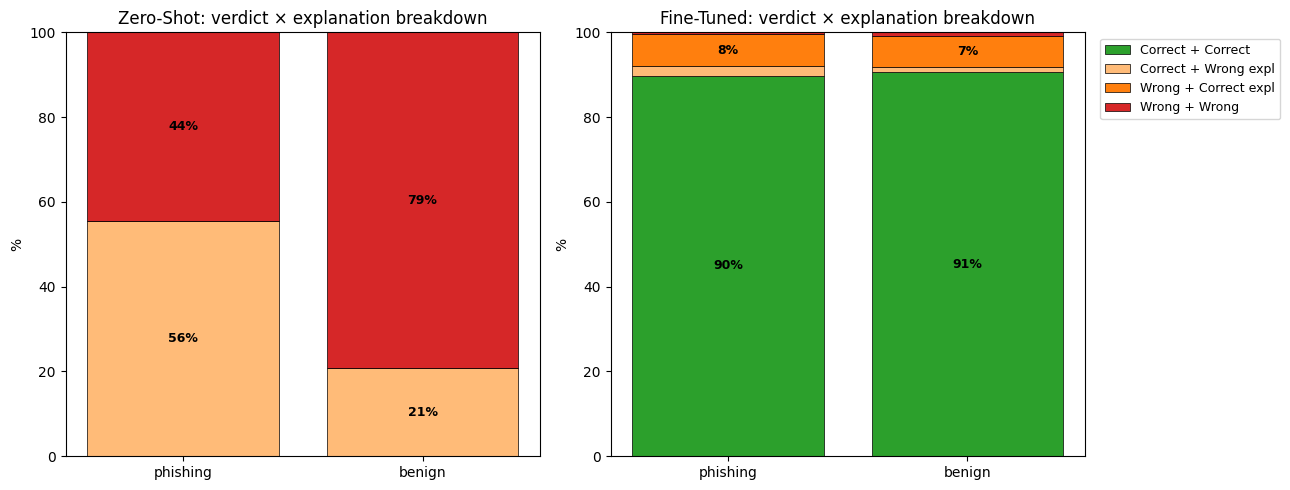

In [42]:
# ── Phase 5f: 4-way verdict × explanation breakdown ──────────────────────────
def four_way_breakdown(results_df, per_row_df, model_name):
    # Merge results with per-row grounding
    df = results_df.merge(per_row_df, on='eval_idx', how='left').fillna(0)

    # Force string columns to plain Python str (avoid pyarrow-backed comparison issues)
    df['predicted_verdict'] = df['predicted_verdict'].astype(object).where(df['predicted_verdict'].notna(), None)
    df['predicted_label'] = df['predicted_verdict'].apply(
        lambda v: 'parse_fail' if v is None else str(v)
    )
    df['label'] = df['label'].astype(str)

    df['verdict_correct'] = df['label'].values == df['predicted_label'].values
    # Explanation correct = at least one cited feature is supported by input
    df['explanation_correct'] = df['n_supported'] > 0

    print(f'\n══════════════════════════════════════════════════════════════════════')
    print(f'  {model_name}  ({len(df)} samples)')
    print(f'══════════════════════════════════════════════════════════════════════')

    summary = {}
    for cls in ['phishing', 'benign']:
        sub = df[df['label'] == cls]
        cc = ((sub['verdict_correct']) & (sub['explanation_correct'])).sum()
        cw = ((sub['verdict_correct']) & (~sub['explanation_correct'])).sum()
        wc = ((~sub['verdict_correct']) & (sub['explanation_correct'])).sum()
        ww = ((~sub['verdict_correct']) & (~sub['explanation_correct'])).sum()
        n = len(sub)
        print(f'\n  {cls.upper()} ({n}):')
        print(f'    correct verdict + correct expl: {cc:>4}  ({100*cc/n:.1f}%)')
        print(f'    correct verdict + wrong expl:   {cw:>4}  ({100*cw/n:.1f}%)')
        print(f'    wrong verdict   + correct expl: {wc:>4}  ({100*wc/n:.1f}%)')
        print(f'    wrong verdict   + wrong expl:   {ww:>4}  ({100*ww/n:.1f}%)')
        summary[cls] = {'cc': int(cc), 'cw': int(cw), 'wc': int(wc), 'ww': int(ww), 'n': int(n)}
    return summary, df

zs_breakdown, zs_full = four_way_breakdown(zs_df, zs_per_row, 'ZERO-SHOT')
ft_breakdown, ft_full = four_way_breakdown(ft_df, ft_per_row, 'FINE-TUNED')

# Save
with open(PHASE5_DIR / 'four_way_breakdown.json', 'w') as f:
    json.dump({'zero_shot': zs_breakdown, 'fine_tuned': ft_breakdown}, f, indent=2)

# Visualize as side-by-side stacked bars
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
categories = ['CC', 'CW', 'WC', 'WW']
labels_long = ['Correct + Correct', 'Correct + Wrong expl', 'Wrong + Correct expl', 'Wrong + Wrong']
colors = ['#2ca02c', '#ffbb78', '#ff7f0e', '#d62728']

for ax, model_name, bd in [(axes[0], 'Zero-Shot', zs_breakdown), (axes[1], 'Fine-Tuned', ft_breakdown)]:
    classes = ['phishing', 'benign']
    bottom = np.zeros(len(classes))
    for cat, lbl, c in zip(['cc','cw','wc','ww'], labels_long, colors):
        vals = [100*bd[cls][cat]/bd[cls]['n'] for cls in classes]
        ax.bar(classes, vals, bottom=bottom, color=c, label=lbl, edgecolor='black', linewidth=0.5)
        for i, v in enumerate(vals):
            if v > 3:
                ax.text(i, bottom[i]+v/2, f'{v:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold')
        bottom += vals
    ax.set_ylim(0, 100)
    ax.set_ylabel('%')
    ax.set_title(f'{model_name}: verdict × explanation breakdown')
    if ax == axes[1]:
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(PHASE5_DIR / 'four_way_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 5g — Confusion matrices, PR curves, ROC curves

Side-by-side comparison plots. Same layout for both models so the reader can directly compare.

Note: since we use greedy decoding (no probabilities), the PR/ROC curves are degenerate at single points. For a proper curve we'd need to extract token logits — added as a small bonus cell if useful.

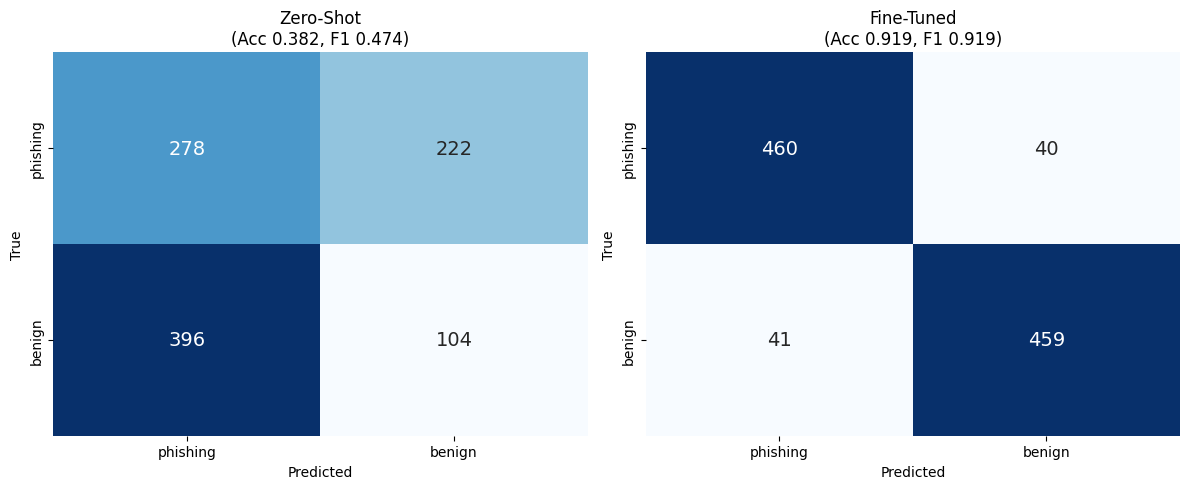

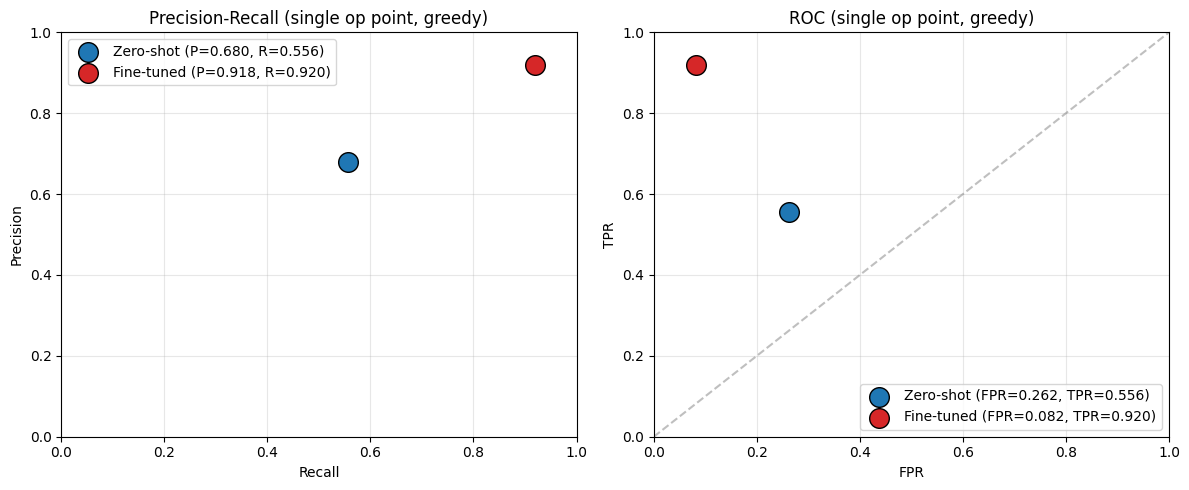

In [43]:
# ── Phase 5g: Confusion matrices side by side ────────────────────────────────
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, m) in zip(axes, [('Zero-Shot', zs_m), ('Fine-Tuned', ft_m)]):
    cm = np.array(m['cm'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['phishing', 'benign'],
                yticklabels=['phishing', 'benign'],
                cbar=False, annot_kws={'size': 14})
    ax.set_title(f'{name}\n(Acc {m["accuracy"]:.3f}, F1 {m["phish_f1"]:.3f})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(PHASE5_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Single-point PR / ROC plot (greedy decoding gives one operating point per model)
from sklearn.metrics import precision_recall_curve, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Build pseudo-probabilities: predicted_phishing_prob = 1 if predicted phishing else 0
for ax, (name, df, color) in zip(axes, [
    ('Zero-Shot vs Fine-Tuned (PR)', None, None),
    ('Zero-Shot vs Fine-Tuned (ROC)', None, None),
]):
    pass

ax_pr, ax_roc = axes
for name, df, color in [('Zero-shot', zs_df, '#1f77b4'), ('Fine-tuned', ft_df, '#d62728')]:
    pp = df.copy()
    pp['pred_lbl'] = pp['predicted_verdict'].fillna('benign')
    y_true = (pp['label'] == 'phishing').astype(int)
    y_prob = (pp['pred_lbl'] == 'phishing').astype(int)   # binary 'prob'
    p = ((y_true==1) & (y_prob==1)).sum() / max((y_prob==1).sum(), 1)
    r = ((y_true==1) & (y_prob==1)).sum() / max((y_true==1).sum(), 1)
    fpr = ((y_true==0) & (y_prob==1)).sum() / max((y_true==0).sum(), 1)
    tpr = r
    ax_pr.scatter([r], [p], s=200, label=f'{name} (P={p:.3f}, R={r:.3f})', color=color, edgecolor='black')
    ax_roc.scatter([fpr], [tpr], s=200, label=f'{name} (FPR={fpr:.3f}, TPR={tpr:.3f})', color=color, edgecolor='black')

ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1)
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall (single op point, greedy)')
ax_pr.legend(); ax_pr.grid(alpha=0.3)

ax_roc.plot([0,1],[0,1], '--', color='gray', alpha=0.5)
ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1)
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title('ROC (single op point, greedy)')
ax_roc.legend(); ax_roc.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PHASE5_DIR / 'pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5h — Per-domain & per-class error analysis

Where does the fine-tuned model fail? Look at:
1. Most-missed domains (top 10 by error count, per model)
2. Domains where fine-tuned regressed vs zero-shot (model got worse after training)
3. Domains where fine-tuned improved most (the wins)

In [44]:
# ── Phase 5h: Per-domain error analysis ──────────────────────────────────────
zs_full['model'] = 'zero_shot'
ft_full['model'] = 'fine_tuned'

# Per-domain error rate for each model
def per_domain_errors(df):
    df = df.copy()
    df['error'] = (~df['verdict_correct']).astype(int)
    by_dom = df.groupby('registered_domain').agg(
        n=('error', 'count'),
        errors=('error', 'sum'),
    )
    by_dom['err_rate'] = by_dom['errors'] / by_dom['n']
    return by_dom.sort_values('errors', ascending=False)

zs_doms = per_domain_errors(zs_full)
ft_doms = per_domain_errors(ft_full)

print('── Top 10 domains with most ZERO-SHOT errors ──')
print(zs_doms.head(10).to_string())

print('\n── Top 10 domains with most FINE-TUNED errors ──')
print(ft_doms.head(10).to_string())

# Domains where fine-tuned regressed
common = zs_doms.index.intersection(ft_doms.index)
delta = pd.DataFrame({
    'n': zs_doms.loc[common, 'n'],
    'zs_err_rate': zs_doms.loc[common, 'err_rate'],
    'ft_err_rate': ft_doms.loc[common, 'err_rate'],
})
delta['delta'] = delta['ft_err_rate'] - delta['zs_err_rate']  # positive = fine-tuned worse

regressions = delta[(delta['delta'] > 0) & (delta['n'] >= 3)].sort_values('delta', ascending=False)
improvements = delta[(delta['delta'] < 0) & (delta['n'] >= 3)].sort_values('delta')

print('\n── Domains where FINE-TUNED REGRESSED (top 10, ≥3 samples) ──')
print(regressions.head(10).to_string())

print('\n── Domains where FINE-TUNED IMPROVED MOST (top 10, ≥3 samples) ──')
print(improvements.head(10).to_string())

# Save
zs_doms.to_csv(PHASE5_DIR / 'per_domain_zero_shot.csv')
ft_doms.to_csv(PHASE5_DIR / 'per_domain_fine_tuned.csv')
delta.to_csv(PHASE5_DIR / 'per_domain_delta.csv')

── Top 10 domains with most ZERO-SHOT errors ──
                        n  errors  err_rate
registered_domain                          
roblox.com.ge          29      23  0.793103
dweb.link             102      22  0.215686
quickstayreserve.com   23      13  0.565217
framer.app             11      10  0.909091
pancake.run             6       6  1.000000
wixsite.com             5       4  0.800000
roblox.com.bn           4       3  0.750000
snapchat.com            3       3  1.000000
hola.org                3       3  1.000000
arxiv.org               3       3  1.000000

── Top 10 domains with most FINE-TUNED errors ──
                                 n  errors  err_rate
registered_domain                                   
pancake.run                      6       2  0.333333
tarifcheck-beste-bank-kredit.de  2       2  1.000000
votrentreprise.com               2       2  1.000000
thoughtlanes.net                 2       2  1.000000
apkshub.com                      2       2  1.000000
rec

## 5i — Side-by-side example outputs

10 examples where the two models gave different verdicts — shows you exactly how fine-tuning changes the model's behaviour on real inputs.

In [45]:
# ── Phase 5i: Side-by-side examples where models disagreed ───────────────────
zs_only = zs_full[['eval_idx', 'id', 'label', 'url', 'predicted_label', 'generated_text']].rename(
    columns={'predicted_label': 'zs_pred', 'generated_text': 'zs_text'})
ft_only = ft_full[['eval_idx', 'predicted_label', 'generated_text']].rename(
    columns={'predicted_label': 'ft_pred', 'generated_text': 'ft_text'})
merged = zs_only.merge(ft_only, on='eval_idx')

disagree = merged[merged['zs_pred'] != merged['ft_pred']]
ft_fixed_zs = disagree[(merged['ft_pred'] == merged['label']) & (merged['zs_pred'] != merged['label'])]
ft_broke_zs = disagree[(merged['zs_pred'] == merged['label']) & (merged['ft_pred'] != merged['label'])]

print(f'Total disagreements: {len(disagree)}')
print(f'  Fine-tuned FIXED zero-shot mistakes:   {len(ft_fixed_zs)}')
print(f'  Fine-tuned BROKE  zero-shot correctness: {len(ft_broke_zs)}')

def show_pair(row, title):
    print('\n' + '═' * 100)
    print(f'  {title}')
    print(f'  TRUE: {row["label"]}  URL: {row["url"][:80]}')
    print('═' * 100)
    print(f'\n── ZERO-SHOT (predicted: {row["zs_pred"]}) ──')
    print(row['zs_text'][:800])
    print(f'\n── FINE-TUNED (predicted: {row["ft_pred"]}) ──')
    print(row['ft_text'][:800])

print('\n\n>>> Examples where FINE-TUNED FIXED ZERO-SHOT <<<')
for _, r in ft_fixed_zs.head(5).iterrows():
    show_pair(r, 'FT FIXED ZS')

print('\n\n>>> Examples where FINE-TUNED BROKE ZERO-SHOT <<<')
for _, r in ft_broke_zs.head(5).iterrows():
    show_pair(r, 'FT BROKE ZS')

Total disagreements: 615
  Fine-tuned FIXED zero-shot mistakes:   559
  Fine-tuned BROKE  zero-shot correctness: 22


>>> Examples where FINE-TUNED FIXED ZERO-SHOT <<<

════════════════════════════════════════════════════════════════════════════════════════════════════
  FT FIXED ZS
  TRUE: benign  URL: https://www.draftsight.com/how-to-buy
════════════════════════════════════════════════════════════════════════════════════════════════════

── ZERO-SHOT (predicted: phishing) ──
Phishing risk factors:
- URL patterns: low entropy (4.13) and low digit ratio (0.00) may indicate a generic or fake URL structure.
- Page structure: high number of tags (571) and scripts (42) may indicate a complex and potentially malicious page layout.
- Content: high text/html ratio (7.0%) may indicate a low-quality or spammy content.
- JS behaviour: presence of hidden elements may indicate an attempt to hide malicious code or content.

Benign mitigating factors:
- Content: presence of a privacy link may indic

## 5j — Final summary table + thesis-ready report

Single CSV that has every metric for both models, plus a markdown summary you can paste straight into a thesis chapter.

In [46]:
# ── Phase 5j: Final summary table ────────────────────────────────────────────
summary_rows = []

for name, m, g, bd in [
    ('zero_shot', zs_m, zs_grounding, zs_breakdown),
    ('fine_tuned', ft_m, ft_grounding, ft_breakdown),
]:
    n_total = m['n_total']
    summary_rows.append({
        'model':                    name,
        'accuracy':                 m['accuracy'],
        'balanced_accuracy':        m['balanced_accuracy'],
        'phishing_f1':              m['phish_f1'],
        'phishing_precision':       m['phish_precision'],
        'phishing_recall':          m['phish_recall'],
        'benign_f1':                m['per_class']['benign']['f1'],
        'macro_f1':                 m['macro_f1'],
        'parse_failure_rate':       m['n_parse_fail'] / n_total,
        'grounding_supported_pct':  g['supported']   / max(g['total_cited'], 1),
        'grounding_contradicted_pct': g['contradicted'] / max(g['total_cited'], 1),
        'grounding_unknown_pct':    g['unknown']     / max(g['total_cited'], 1),
        'phish_correct_correct_pct':  bd['phishing']['cc'] / bd['phishing']['n'],
        'phish_correct_wrong_expl_pct': bd['phishing']['cw'] / bd['phishing']['n'],
        'phish_wrong_correct_expl_pct': bd['phishing']['wc'] / bd['phishing']['n'],
        'phish_wrong_wrong_pct':    bd['phishing']['ww'] / bd['phishing']['n'],
        'benign_correct_correct_pct':  bd['benign']['cc'] / bd['benign']['n'],
        'benign_correct_wrong_expl_pct': bd['benign']['cw'] / bd['benign']['n'],
        'benign_wrong_correct_expl_pct': bd['benign']['wc'] / bd['benign']['n'],
        'benign_wrong_wrong_pct':    bd['benign']['ww'] / bd['benign']['n'],
    })

summary_df = pd.DataFrame(summary_rows).set_index('model').T
summary_df['delta'] = summary_df['fine_tuned'] - summary_df['zero_shot']
summary_df.to_csv(PHASE5_DIR / 'final_summary.csv')
print(summary_df.round(4).to_string())

# Markdown report
report = f"""# Phishing Detection Fine-Tuning — Final Results

## Headline numbers
|                      | Zero-Shot | Fine-Tuned | Δ |
|----------------------|-----------|------------|----|
| Accuracy             | {zs_m['accuracy']:.4f} | {ft_m['accuracy']:.4f} | {ft_m['accuracy']-zs_m['accuracy']:+.4f} |
| Phishing F1          | {zs_m['phish_f1']:.4f} | {ft_m['phish_f1']:.4f} | {ft_m['phish_f1']-zs_m['phish_f1']:+.4f} |
| Phishing recall      | {zs_m['phish_recall']:.4f} | {ft_m['phish_recall']:.4f} | {ft_m['phish_recall']-zs_m['phish_recall']:+.4f} |
| Parse failure rate   | {zs_m['n_parse_fail']/zs_m['n_total']:.1%} | {ft_m['n_parse_fail']/ft_m['n_total']:.1%} | — |
| Grounding (supported)| {zs_grounding['supported']/max(zs_grounding['total_cited'],1):.1%} | {ft_grounding['supported']/max(ft_grounding['total_cited'],1):.1%} | — |
| Hallucination rate   | {zs_grounding['unknown']/max(zs_grounding['total_cited'],1):.1%} | {ft_grounding['unknown']/max(ft_grounding['total_cited'],1):.1%} | — |

## 4-way verdict × explanation breakdown

### Phishing (n={zs_breakdown['phishing']['n']})
|                            | Zero-Shot | Fine-Tuned |
|----------------------------|-----------|------------|
| Verdict + expl both correct| {zs_breakdown['phishing']['cc']/zs_breakdown['phishing']['n']:.1%} | {ft_breakdown['phishing']['cc']/ft_breakdown['phishing']['n']:.1%} |
| Verdict correct, expl wrong| {zs_breakdown['phishing']['cw']/zs_breakdown['phishing']['n']:.1%} | {ft_breakdown['phishing']['cw']/ft_breakdown['phishing']['n']:.1%} |
| Verdict wrong, expl correct| {zs_breakdown['phishing']['wc']/zs_breakdown['phishing']['n']:.1%} | {ft_breakdown['phishing']['wc']/ft_breakdown['phishing']['n']:.1%} |
| Both wrong                 | {zs_breakdown['phishing']['ww']/zs_breakdown['phishing']['n']:.1%} | {ft_breakdown['phishing']['ww']/ft_breakdown['phishing']['n']:.1%} |

### Benign (n={zs_breakdown['benign']['n']})
|                            | Zero-Shot | Fine-Tuned |
|----------------------------|-----------|------------|
| Verdict + expl both correct| {zs_breakdown['benign']['cc']/zs_breakdown['benign']['n']:.1%} | {ft_breakdown['benign']['cc']/ft_breakdown['benign']['n']:.1%} |
| Verdict correct, expl wrong| {zs_breakdown['benign']['cw']/zs_breakdown['benign']['n']:.1%} | {ft_breakdown['benign']['cw']/ft_breakdown['benign']['n']:.1%} |
| Verdict wrong, expl correct| {zs_breakdown['benign']['wc']/zs_breakdown['benign']['n']:.1%} | {ft_breakdown['benign']['wc']/ft_breakdown['benign']['n']:.1%} |
| Both wrong                 | {zs_breakdown['benign']['ww']/zs_breakdown['benign']['n']:.1%} | {ft_breakdown['benign']['ww']/ft_breakdown['benign']['n']:.1%} |

## Output files
- `classification_metrics.json` — all per-model metrics
- `grounding_comparison.json` — grounding breakdown
- `four_way_breakdown.json` — verdict×explanation table
- `final_summary.csv` — single CSV with everything
- `confusion_matrices.png`, `four_way_breakdown.png`, `pr_roc_curves.png` — plots
- `per_domain_*.csv` — error analysis by domain
"""

with open(PHASE5_DIR / 'final_report.md', 'w') as f:
    f.write(report)

print('\n' + '═' * 70)
print('  PHASE 5 COMPLETE')
print('═' * 70)
print(f'\nAll outputs saved under: {PHASE5_DIR}')
print(f'\nKey file for thesis: {PHASE5_DIR / "final_report.md"}')

model                          zero_shot  fine_tuned   delta
accuracy                          0.3820      0.9190  0.5370
balanced_accuracy                 0.3820      0.9190  0.5370
phishing_f1                       0.4736      0.9191  0.4455
phishing_precision                0.4125      0.9182  0.5057
phishing_recall                   0.5560      0.9200  0.3640
benign_f1                         0.2518      0.9189  0.6671
macro_f1                          0.3627      0.9190  0.5563
parse_failure_rate                0.4630      0.0000 -0.4630
grounding_supported_pct           0.0000      0.7498  0.7498
grounding_contradicted_pct        0.0000      0.2502  0.2502
grounding_unknown_pct             0.0000      0.0000  0.0000
phish_correct_correct_pct         0.0000      0.8980  0.8980
phish_correct_wrong_expl_pct      0.5560      0.0220 -0.5340
phish_wrong_correct_expl_pct      0.0000      0.0760  0.0760
phish_wrong_wrong_pct             0.4440      0.0040 -0.4400
benign_correct_correct_p